In [26]:
import asyncio
from sipyco.sync_struct import Subscriber

# Create an asyncio Event to wait for updates
dataset_updated = asyncio.Event()


async def connect_subscriber(name, db: dict, port=None, server=None):
    port = 3250 if port is None else port
    server = "137.222.69.28" if server is None else server

    def _create(data):
        db.update(data)
        return db

    def _update(mod):
        # Signal that an update has occurred
        dataset_updated.set()

    subscriber = Subscriber(name, _create, _update, None)
    try:
        await subscriber.connect(
            server,
            port,
        )
    except asyncio.TimeoutError:
        print(f"Failed to connect to Sub: {name} at {server}:{port}")
        return
    print(f"Connected to Sub: {name} at {server}:{port}")
    return subscriber

**DO NOT add extra code to this lower cell.**

Due to jupyter notebook async weirdness it won't actually await the return before running subsequent code

In [27]:
# Run the connection in an asyncio event loop
db = {}
sub = await connect_subscriber("datasets", db)
await dataset_updated.wait()
# await sub.close()
print("Received dataset update!")

Connected to Sub: datasets at 137.222.69.28:3250
Received dataset update!


In [28]:
import numpy as np

# get the RID of the latest dataset
keys = list(db.keys())
# find ones with ndscan.rid_NUM.source_id
rid_keys = [
    key.split(".")[1][4:]
    for key in keys
    if key.startswith("ndscan.rid_") and key.endswith(".source_id")
]
if rid_keys:
    RID = rid_keys[-1]  # Get the last RID in the list
else:
    raise ValueError("No ndscan datasets found.")
print(f"Selected RID: {RID} from {rid_keys}")

print(f"Dataset keys: {list(db.keys())}")


Selected RID: 28374 from ['28374']
Dataset keys: ['fastino.leds', 'fastino.voltages', 'mirny.atts', 'mirny.en_almazny', 'mirny.en_outs', 'mirny.freqs', 'suservo.Gls', 'suservo.Is', 'suservo.Ps', 'suservo.atts', 'suservo.calib_gains', 'suservo.calib_offsets', 'suservo.en_iirs', 'suservo.en_outs', 'suservo.en_shutters', 'suservo.enabled', 'suservo.freqs', 'suservo.gains', 'suservo.offsets', 'suservo.ys', 'Images.absorption.TOF', 'Images.absorption.REF', 'Images.absorption.BG', 'Images.absorption.expansion_time', 'Images.absorption.settings', 'Images.absorption.timestamp', 'ndscan.rid_28374.ndscan_schema_revision', 'ndscan.rid_28374.source_id', 'ndscan.rid_28374.completed', 'ndscan.rid_28374.execution_mode', 'ndscan.rid_28374.fragment_fqn', 'ndscan.rid_28374.axes', 'ndscan.rid_28374.seed', 'ndscan.rid_28374.channels', 'ndscan.rid_28374.annotations', 'ndscan.rid_28374.online_analyses', 'ndscan.rid_28374.analysis_results', 'ndscan.rid_28374.points.channel_atom_number', 'ndscan.rid_28374.poi

Num points: 53
Failed shots: 0.00%
Mean atom number: 1.72e8 +- 0.07e8
std: 4.02%


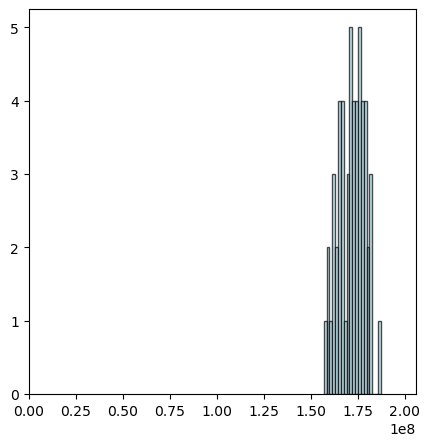

In [50]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib import colors


axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

fig, ax = plt.subplots(1, num_axes, figsize=(5 * num_axes, 5))
if num_axes == 1:
    ax = [ax]  # Ensure ax is always a list for consistency

for i in range(num_axes):
    # make histogram
    N, bins, patches = ax[i].hist(
        np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]),
        bins=20,
        alpha=0.7,
        color="lightblue",
        edgecolor="black",
    )
    ax[i].set_xlim(0, max(np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]))*1.1)
    

    

numbers = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots(atom < 30% mean )
# failed_shots = np.sum(numbers < 0.7 * np.mean(numbers))
failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e8:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")

# for i in range(1,num_axes):
#     ax[i].axhline(np.mean(numbers), color='b', linestyle='--', )
# ax[0].axhline(np.mean(numbers), color='b', linestyle='--', label='Mean = {:.2f}e8'.format(np.mean(numbers) / 1e8))
# ax[0].legend(loc="lower right")

# atom number and uncertainty
print(
    f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8"
)
print(f"std: {np.std(numbers) / np.mean(numbers) * 100:.2f}%")

Task was destroyed but it is pending!
task: <Task pending name='Task-10' coro=<Subscriber._receive_cr() running at /home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/sipyco/sync_struct.py:149> wait_for=<Future pending cb=[Task.task_wakeup()]>>


Text(0.5, 1.0, 'Old Histogram of Atom Numbers')

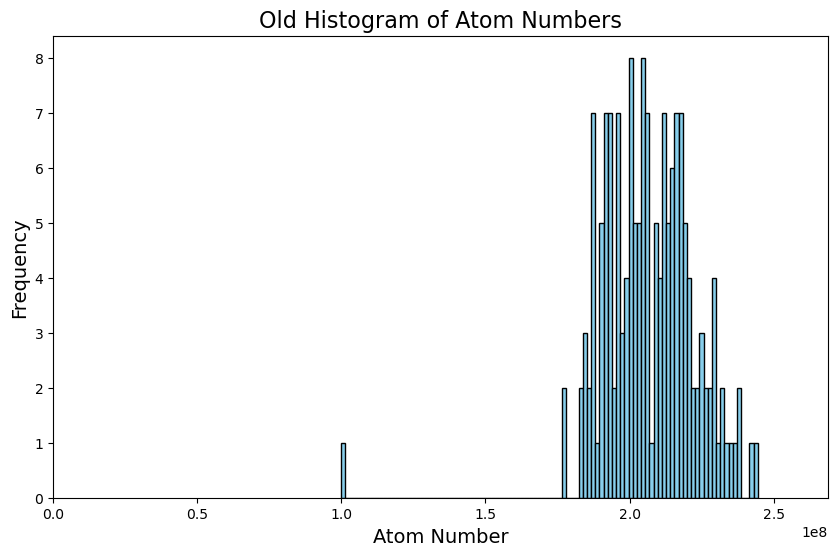

In [30]:
import pandas as pd

df = pd.DataFrame([
    {
        "point_index": 0,
        "timestamp": 39.30157823394984,
        "atom_number": 206905998.15135932,
        "custom_objective": 0.024604591624336515,
        "gaussian_fit_centre_x": 319.9554275691908,
        "gaussian_fit_centre_y": 229.1757129499571,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 206905998.15135932,\n            "peak_pixel": (219, 304, 3.602749027578081),\n            "centroid_pixel": (229, 320, 3.2413631200451536),\n            "best_values_pixel": {\'A\': 3.409669180363004, \'x0\': 319.9554275691908, \'y0\': 229.1757129499571, \'sx\': 81.31634739024412, \'sy\': 68.11328183411287, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2651127393137834.0, 2.961156035142131e-08, 6.883581761976157e-08),\n            "peak_optical_density": 3.602749027578081,\n            "Peak density (atoms/cm^3)": 2.65e+09,\n            "sigmax": 81.31634739024412,\n            "sigmay": 68.11328183411287,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.602749027578081,
        "phase_space_density": 6.883581761976157e-8,
        "sigmax": 81.31634739024412,
        "sigmax_mm": 1.8085877264381882,
        "sigmay": 68.11328183411287,
        "sigmay_mm": 1.514933337344924,
    },
    {
        "point_index": 1,
        "timestamp": 72.51771246292628,
        "atom_number": 216346321.59037322,
        "custom_objective": 0.0847913143640878,
        "gaussian_fit_centre_x": 319.36925684452945,
        "gaussian_fit_centre_y": 230.07692840772503,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216346321.59037322,\n            "peak_pixel": (228, 308, 3.6277983553527036),\n            "centroid_pixel": (237, 318, 3.162016663864019),\n            "best_values_pixel": {\'A\': 3.3405660440588294, \'x0\': 319.36925684452945, \'y0\': 230.07692840772503, \'sx\': 84.67184201801753, \'sy\': 70.14781125522133, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2482575255328407.0, 2.961156035142131e-08, 6.445940619279571e-08),\n            "peak_optical_density": 3.6277983553527036,\n            "Peak density (atoms/cm^3)": 2.48e+09,\n            "sigmax": 84.67184201801753,\n            "sigmay": 70.14781125522133,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6277983553527036,
        "phase_space_density": 6.445940619279571e-8,
        "sigmax": 84.67184201801753,
        "sigmax_mm": 1.883218555228321,
        "sigmay": 70.14781125522133,
        "sigmay_mm": 1.5601840779178537,
    },
    {
        "point_index": 2,
        "timestamp": 105.77215633098967,
        "atom_number": 196530497.03345442,
        "custom_objective": 0.14387538937421013,
        "gaussian_fit_centre_x": 319.44161345419474,
        "gaussian_fit_centre_y": 229.35154304051687,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 196530497.03345442,\n            "peak_pixel": (218, 313, 3.290785571762144),\n            "centroid_pixel": (235, 318, 2.9081839901544324),\n            "best_values_pixel": {\'A\': 3.1078602452959974, \'x0\': 319.44161345419474, \'y0\': 229.35154304051687, \'sx\': 83.26007431241949, \'sy\': 69.60010395128265, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2350669233591234.0, 2.961156035142131e-08, 6.103450142256452e-08),\n            "peak_optical_density": 3.290785571762144,\n            "Peak density (atoms/cm^3)": 2.35e+09,\n            "sigmax": 83.26007431241949,\n            "sigmay": 69.60010395128265,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.290785571762144,
        "phase_space_density": 6.103450142256452e-8,
        "sigmax": 83.26007431241949,
        "sigmax_mm": 1.8518188941900195,
        "sigmay": 69.60010395128265,
        "sigmay_mm": 1.5480023120199073,
    },
    {
        "point_index": 3,
        "timestamp": 138.98639245680533,
        "atom_number": 209166084.13526696,
        "custom_objective": -0.010913760844927824,
        "gaussian_fit_centre_x": 319.9672595086284,
        "gaussian_fit_centre_y": 230.04604288002682,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 209166084.13526696,\n            "peak_pixel": (218, 303, 3.6929779256061246),\n            "centroid_pixel": (229, 320, 3.3098703676210226),\n            "best_values_pixel": {\'A\': 3.501630625794655, \'x0\': 319.9672595086284, \'y0\': 230.04604288002682, \'sx\': 80.71181879383948, \'sy\': 67.50475646999291, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2744907225049040.5, 2.961156035142131e-08, 7.127078601191084e-08),\n            "peak_optical_density": 3.6929779256061246,\n            "Peak density (atoms/cm^3)": 2.74e+09,\n            "sigmax": 80.71181879383948,\n            "sigmay": 67.50475646999291,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6929779256061246,
        "phase_space_density": 7.127078601191084e-8,
        "sigmax": 80.71181879383948,
        "sigmax_mm": 1.7951421766216022,
        "sigmay": 67.50475646999291,
        "sigmay_mm": 1.5013988939015666,
    },
    {
        "point_index": 4,
        "timestamp": 172.21171406190842,
        "atom_number": 191473495.9378356,
        "custom_objective": 0.0671676095796765,
        "gaussian_fit_centre_x": 319.45285443325935,
        "gaussian_fit_centre_y": 229.6981386548558,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 191473495.9378356,\n            "peak_pixel": (222, 332, 3.3800556260869628),\n            "centroid_pixel": (228, 319, 3.1125207591784134),\n            "best_values_pixel": {\'A\': 3.2246111924610137, \'x0\': 319.45285443325935, \'y0\': 229.6981386548558, \'sx\': 80.45242155558883, \'sy\': 67.25907047435534, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2538192823443563.0, 2.961156035142131e-08, 6.590350155582472e-08),\n            "peak_optical_density": 3.3800556260869628,\n            "Peak density (atoms/cm^3)": 2.54e+09,\n            "sigmax": 80.45242155558883,\n            "sigmay": 67.25907047435534,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3800556260869628,
        "phase_space_density": 6.590350155582472e-8,
        "sigmax": 80.45242155558883,
        "sigmax_mm": 1.7893728242536135,
        "sigmay": 67.25907047435534,
        "sigmay_mm": 1.4959344984813514,
    },
    {
        "point_index": 5,
        "timestamp": 205.4291277548764,
        "atom_number": 198679971.6331058,
        "custom_objective": 0.05145870101463275,
        "gaussian_fit_centre_x": 320.0683049195294,
        "gaussian_fit_centre_y": 229.9944020476428,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 198679971.6331058,\n            "peak_pixel": (229, 323, 3.583013429915732),\n            "centroid_pixel": (230, 320, 3.3125361741433004),\n            "best_values_pixel": {\'A\': 3.304101240437708, \'x0\': 320.0683049195294, \'y0\': 229.9944020476428, \'sx\': 80.94864480133, \'sy\': 67.79991551290938, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2580779017023559.5, 2.961156035142131e-08, 6.700924074511463e-08),\n            "peak_optical_density": 3.583013429915732,\n            "Peak density (atoms/cm^3)": 2.58e+09,\n            "sigmax": 80.94864480133,\n            "sigmay": 67.79991551290938,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.583013429915732,
        "phase_space_density": 6.700924074511463e-8,
        "sigmax": 80.94864480133,
        "sigmax_mm": 1.8004095136847535,
        "sigmay": 67.79991551290938,
        "sigmay_mm": 1.5079636381319501,
    },
    {
        "point_index": 6,
        "timestamp": 238.63534466386773,
        "atom_number": 195550876.82320556,
        "custom_objective": 0.08505440571326899,
        "gaussian_fit_centre_x": 320.3017538568019,
        "gaussian_fit_centre_y": 230.65752614942224,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 195550876.82320556,\n            "peak_pixel": (229, 322, 3.3817566538601462),\n            "centroid_pixel": (231, 320, 3.2044143333504187),\n            "best_values_pixel": {\'A\': 3.215149094795204, \'x0\': 320.3017538568019, \'y0\': 230.65752614942224, \'sx\': 80.95386496404822, \'sy\': 68.60122729046674, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2510138896218797.0, 2.961156035142131e-08, 6.517508879717701e-08),\n            "peak_optical_density": 3.3817566538601462,\n            "Peak density (atoms/cm^3)": 2.51e+09,\n            "sigmax": 80.95386496404822,\n            "sigmay": 68.60122729046674,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3817566538601462,
        "phase_space_density": 6.517508879717701e-8,
        "sigmax": 80.95386496404822,
        "sigmax_mm": 1.800525617303831,
        "sigmay": 68.60122729046674,
        "sigmay_mm": 1.52578591732245,
    },
    {
        "point_index": 7,
        "timestamp": 271.85494107590057,
        "atom_number": 232577233.3607906,
        "custom_objective": 0.005080171320596932,
        "gaussian_fit_centre_x": 320.54691450907717,
        "gaussian_fit_centre_y": 230.76601321367295,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 232577233.3607906,\n            "peak_pixel": (242, 312, 3.839434855132694),\n            "centroid_pixel": (237, 320, 3.3521002625350316),\n            "best_values_pixel": {\'A\': 3.6125899272458826, \'x0\': 320.54691450907717, \'y0\': 230.76601321367295, \'sx\': 84.28515271061258, \'sy\': 70.12428366651146, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2694273337542110.0, 2.961156035142131e-08, 6.995609059032219e-08),\n            "peak_optical_density": 3.839434855132694,\n            "Peak density (atoms/cm^3)": 2.69e+09,\n            "sigmax": 84.28515271061258,\n            "sigmay": 70.12428366651146,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.839434855132694,
        "phase_space_density": 6.995609059032219e-8,
        "sigmax": 84.28515271061258,
        "sigmax_mm": 1.874618051667073,
        "sigmay": 70.12428366651146,
        "sigmay_mm": 1.5596607918930998,
    },
    {
        "point_index": 8,
        "timestamp": 305.06227737199515,
        "atom_number": 193589521.58739343,
        "custom_objective": 0.08695193542445206,
        "gaussian_fit_centre_x": 318.2782210029603,
        "gaussian_fit_centre_y": 229.3945009132021,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 193589521.58739343,\n            "peak_pixel": (222, 333, 3.4020003799839302),\n            "centroid_pixel": (228, 318, 3.2377398750477324),\n            "best_values_pixel": {\'A\': 3.195066092024623, \'x0\': 318.2782210029603, \'y0\': 229.3945009132021, \'sx\': 81.01596407251277, \'sy\': 68.17570633214244, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2496640659026696.0, 2.961156035142131e-08, 6.482461065872588e-08),\n            "peak_optical_density": 3.4020003799839302,\n            "Peak density (atoms/cm^3)": 2.50e+09,\n            "sigmax": 81.01596407251277,\n            "sigmay": 68.17570633214244,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4020003799839302,
        "phase_space_density": 6.482461065872588e-8,
        "sigmax": 81.01596407251277,
        "sigmax_mm": 1.8019067871300254,
        "sigmay": 68.17570633214244,
        "sigmay_mm": 1.5163217442838577,
    },
    {
        "point_index": 9,
        "timestamp": 338.2771264198236,
        "atom_number": 186007108.5117563,
        "custom_objective": 0.12382044438027065,
        "gaussian_fit_centre_x": 318.5618109062805,
        "gaussian_fit_centre_y": 230.00249057213549,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 186007108.5117563,\n            "peak_pixel": (236, 309, 3.332797006549013),\n            "centroid_pixel": (230, 318, 3.068816049637815),\n            "best_values_pixel": {\'A\': 3.0787262245914637, \'x0\': 318.5618109062805, \'y0\': 230.00249057213549, \'sx\': 81.18646623706046, \'sy\': 67.89267734835101, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2398746624036772.5, 2.961156035142131e-08, 6.228281807792756e-08),\n            "peak_optical_density": 3.332797006549013,\n            "Peak density (atoms/cm^3)": 2.40e+09,\n            "sigmax": 81.18646623706046,\n            "sigmay": 67.89267734835101,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.332797006549013,
        "phase_space_density": 6.228281807792756e-8,
        "sigmax": 81.18646623706046,
        "sigmax_mm": 1.8056989904449654,
        "sigmay": 67.89267734835101,
        "sigmay_mm": 1.5100267892995312,
    },
    {
        "point_index": 10,
        "timestamp": 371.5089212569874,
        "atom_number": 215727893.7193365,
        "custom_objective": -0.0013813895592979242,
        "gaussian_fit_centre_x": 317.3664943266457,
        "gaussian_fit_centre_y": 229.10228766219697,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 215727893.7193365,\n            "peak_pixel": (237, 324, 3.719417989521342),\n            "centroid_pixel": (228, 317, 3.3698722829626053),\n            "best_values_pixel": {\'A\': 3.5118419551833693, \'x0\': 317.3664943266457, \'y0\': 229.10228766219697, \'sx\': 81.45124064571742, \'sy\': 68.71903741055235, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2730730716555374.0, 2.961156035142131e-08, 7.09026967395202e-08),\n            "peak_optical_density": 3.719417989521342,\n            "Peak density (atoms/cm^3)": 2.73e+09,\n            "sigmax": 81.45124064571742,\n            "sigmay": 68.71903741055235,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.719417989521342,
        "phase_space_density": 7.09026967395202e-8,
        "sigmax": 81.45124064571742,
        "sigmax_mm": 1.811587938499577,
        "sigmay": 68.71903741055235,
        "sigmay_mm": 1.5284061768898711,
    },
    {
        "point_index": 11,
        "timestamp": 404.7711998699233,
        "atom_number": 204423389.18027258,
        "custom_objective": 0.07556690052002933,
        "gaussian_fit_centre_x": 321.46835014853286,
        "gaussian_fit_centre_y": 229.78324902435517,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 204423389.18027258,\n            "peak_pixel": (235, 322, 3.434400782737418),\n            "centroid_pixel": (230, 321, 3.311250796365501),\n            "best_values_pixel": {\'A\': 3.284167441074569, \'x0\': 321.46835014853286, \'y0\': 229.78324902435517, \'sx\': 82.69721131378441, \'sy\': 68.73515332172228, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2509660622191143.0, 2.961156035142131e-08, 6.516267053925961e-08),\n            "peak_optical_density": 3.434400782737418,\n            "Peak density (atoms/cm^3)": 2.51e+09,\n            "sigmax": 82.69721131378441,\n            "sigmay": 68.73515332172228,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.434400782737418,
        "phase_space_density": 6.516267053925961e-8,
        "sigmax": 82.69721131378441,
        "sigmax_mm": 1.8393000447376187,
        "sigmay": 68.73515332172228,
        "sigmay_mm": 1.5287646169831333,
    },
    {
        "point_index": 12,
        "timestamp": 437.9632610529661,
        "atom_number": 187936834.88509545,
        "custom_objective": 0.08673031724534958,
        "gaussian_fit_centre_x": 318.93578560794884,
        "gaussian_fit_centre_y": 229.64943767085188,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 187936834.88509545,\n            "peak_pixel": (217, 319, 3.3975673734142173),\n            "centroid_pixel": (229, 319, 3.1284001963122057),\n            "best_values_pixel": {\'A\': 3.1643193795114453, \'x0\': 318.93578560794884, \'y0\': 229.64943767085188, \'sx\': 80.52078970035122, \'sy\': 67.24315796813326, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2487670198236933.5, 2.961156035142131e-08, 6.459169503027e-08),\n            "peak_optical_density": 3.3975673734142173,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 80.52078970035122,\n            "sigmay": 67.24315796813326,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3975673734142173,
        "phase_space_density": 6.459169503027e-8,
        "sigmax": 80.52078970035122,
        "sigmax_mm": 1.7908934260940184,
        "sigmay": 67.24315796813326,
        "sigmay_mm": 1.4955805823946882,
    },
    {
        "point_index": 13,
        "timestamp": 471.17305581481196,
        "atom_number": 206324376.98977125,
        "custom_objective": 0.07351439871298823,
        "gaussian_fit_centre_x": 318.3304586234144,
        "gaussian_fit_centre_y": 228.45730657144688,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 206324376.98977125,\n            "peak_pixel": (229, 323, 3.4625394635675177),\n            "centroid_pixel": (228, 318, 3.274684932268771),\n            "best_values_pixel": {\'A\': 3.2963939397616135, \'x0\': 318.3304586234144, \'y0\': 228.45730657144688, \'sx\': 82.57982393684328, \'sy\': 69.16422736041774, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2524446403801397.0, 2.961156035142131e-08, 6.554657942606887e-08),\n            "peak_optical_density": 3.4625394635675177,\n            "Peak density (atoms/cm^3)": 2.52e+09,\n            "sigmax": 82.57982393684328,\n            "sigmay": 69.16422736041774,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4625394635675177,
        "phase_space_density": 6.554657942606887e-8,
        "sigmax": 82.57982393684328,
        "sigmax_mm": 1.8366891875608249,
        "sigmay": 69.16422736041774,
        "sigmay_mm": 1.5383078154299807,
    },
    {
        "point_index": 14,
        "timestamp": 504.41596707492135,
        "atom_number": 242309662.82786408,
        "custom_objective": -0.023096912748460124,
        "gaussian_fit_centre_x": 316.8701285084121,
        "gaussian_fit_centre_y": 230.3577770917477,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 242309662.82786408,\n            "peak_pixel": (217, 319, 3.9674258389016264),\n            "centroid_pixel": (236, 316, 3.638013762758875),\n            "best_values_pixel": {\'A\': 3.728904336231081, \'x0\': 316.8701285084121, \'y0\': 230.3577770917477, \'sx\': 84.39537813114784, \'sy\': 70.63367020798205, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2779500013727389.5, 2.961156035142131e-08, 7.216897856900385e-08),\n            "peak_optical_density": 3.9674258389016264,\n            "Peak density (atoms/cm^3)": 2.78e+09,\n            "sigmax": 84.39537813114784,\n            "sigmay": 70.63367020798205,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.9674258389016264,
        "phase_space_density": 7.216897856900385e-8,
        "sigmax": 84.39537813114784,
        "sigmax_mm": 1.8770696170548398,
        "sigmay": 70.63367020798205,
        "sigmay_mm": 1.5709902511775318,
    },
    {
        "point_index": 15,
        "timestamp": 537.6374013309833,
        "atom_number": 192463638.17672178,
        "custom_objective": 0.0696179844551973,
        "gaussian_fit_centre_x": 316.67888423133735,
        "gaussian_fit_centre_y": 230.2955984881385,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 192463638.17672178,\n            "peak_pixel": (229, 322, 3.3734645642677465),\n            "centroid_pixel": (227, 317, 3.1834324822876967),\n            "best_values_pixel": {\'A\': 3.214729439902091, \'x0\': 316.67888423133735, \'y0\': 230.2955984881385, \'sx\': 80.84281451447987, \'sy\': 67.27463689997535, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2526152275248444.0, 2.961156035142131e-08, 6.55908719244662e-08),\n            "peak_optical_density": 3.3734645642677465,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 80.84281451447987,\n            "sigmay": 67.27463689997535,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3734645642677465,
        "phase_space_density": 6.55908719244662e-8,
        "sigmax": 80.84281451447987,
        "sigmax_mm": 1.798055702132397,
        "sigmay": 67.27463689997535,
        "sigmay_mm": 1.4962807172580723,
    },
    {
        "point_index": 16,
        "timestamp": 570.8553248639219,
        "atom_number": 211860701.9066511,
        "custom_objective": 0.05622955986588045,
        "gaussian_fit_centre_x": 317.56485339905356,
        "gaussian_fit_centre_y": 230.35819870041107,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211860701.9066511,\n            "peak_pixel": (235, 323, 3.603142832063796),\n            "centroid_pixel": (230, 318, 3.3187685313772275),\n            "best_values_pixel": {\'A\': 3.36612984360251, \'x0\': 317.56485339905356, \'y0\': 230.35819870041107, \'sx\': 83.68226060416369, \'sy\': 68.672709262519, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2542403425828280.5, 2.961156035142131e-08, 6.601282872681394e-08),\n            "peak_optical_density": 3.603142832063796,\n            "Peak density (atoms/cm^3)": 2.54e+09,\n            "sigmax": 83.68226060416369,\n            "sigmay": 68.672709262519,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.603142832063796,
        "phase_space_density": 6.601282872681394e-8,
        "sigmax": 83.68226060416369,
        "sigmax_mm": 1.8612088996443301,
        "sigmay": 68.672709262519,
        "sigmay_mm": 1.5273757749767158,
    },
    {
        "point_index": 17,
        "timestamp": 604.0681619218085,
        "atom_number": 196625814.4660838,
        "custom_objective": 0.06300655981894972,
        "gaussian_fit_centre_x": 317.3944918591517,
        "gaussian_fit_centre_y": 228.92485401020443,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 196625814.4660838,\n            "peak_pixel": (243, 305, 3.426023322847754),\n            "centroid_pixel": (227, 317, 3.2603654453112725),\n            "best_values_pixel": {\'A\': 3.2605387573414513, \'x0\': 317.3944918591517, \'y0\': 228.92485401020443, \'sx\': 80.67948716603479, \'sy\': 68.07850611317956, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2560644606598265.5, 2.961156035142131e-08, 6.648645613374349e-08),\n            "peak_optical_density": 3.426023322847754,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 80.67948716603479,\n            "sigmay": 68.07850611317956,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.426023322847754,
        "phase_space_density": 6.648645613374349e-8,
        "sigmax": 80.67948716603479,
        "sigmax_mm": 1.7944230766238771,
        "sigmay": 68.07850611317956,
        "sigmay_mm": 1.5141598773448557,
    },
    {
        "point_index": 18,
        "timestamp": 637.2768623288721,
        "atom_number": 208878724.03779107,
        "custom_objective": 0.1330339440437395,
        "gaussian_fit_centre_x": 317.7657051980846,
        "gaussian_fit_centre_y": 230.181803972222,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 208878724.03779107,\n            "peak_pixel": (224, 316, 3.330390307810253),\n            "centroid_pixel": (234, 317, 2.932391535890695),\n            "best_values_pixel": {\'A\': 3.1922519386834947, \'x0\': 317.7657051980846, \'y0\': 230.181803972222, \'sx\': 84.82338063626635, \'sy\': 70.63745128765176, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2371772765017849.5, 2.961156035142131e-08, 6.158244900296957e-08),\n            "peak_optical_density": 3.330390307810253,\n            "Peak density (atoms/cm^3)": 2.37e+09,\n            "sigmax": 84.82338063626635,\n            "sigmay": 70.63745128765176,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.330390307810253,
        "phase_space_density": 6.158244900296957e-8,
        "sigmax": 84.82338063626635,
        "sigmax_mm": 1.8865889831169584,
        "sigmay": 70.63745128765176,
        "sigmay_mm": 1.5710743476046682,
    },
    {
        "point_index": 19,
        "timestamp": 670.4839978979435,
        "atom_number": 215462243.04099473,
        "custom_objective": 0.018157008456260615,
        "gaussian_fit_centre_x": 319.69741435921895,
        "gaussian_fit_centre_y": 229.29287944315413,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 215462243.04099473,\n            "peak_pixel": (251, 316, 3.5989783997416165),\n            "centroid_pixel": (228, 320, 3.434100370163099),\n            "best_values_pixel": {\'A\': 3.4673885726558984, \'x0\': 319.69741435921895, \'y0\': 229.29287944315413, \'sx\': 81.84865318919768, \'sy\': 69.22507393826905, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2681203147804409.5, 2.961156035142131e-08, 6.961672659017311e-08),\n            "peak_optical_density": 3.5989783997416165,\n            "Peak density (atoms/cm^3)": 2.68e+09,\n            "sigmax": 81.84865318919768,\n            "sigmay": 69.22507393826905,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5989783997416165,
        "phase_space_density": 6.961672659017311e-8,
        "sigmax": 81.84865318919768,
        "sigmax_mm": 1.8204269416218104,
        "sigmay": 69.22507393826905,
        "sigmay_mm": 1.539661127247708,
    },
    {
        "point_index": 20,
        "timestamp": 703.7209012568928,
        "atom_number": 193452041.9522516,
        "custom_objective": 0.03912857858261471,
        "gaussian_fit_centre_x": 319.3473803533961,
        "gaussian_fit_centre_y": 227.98827523690377,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 193452041.9522516,\n            "peak_pixel": (242, 328, 3.384728372942953),\n            "centroid_pixel": (224, 319, 3.1077398514067354),\n            "best_values_pixel": {\'A\': 3.2865145582791793, \'x0\': 319.3473803533961, \'y0\': 227.98827523690377, \'sx\': 79.65960703834821, \'sy\': 67.12899189519061, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2620788176614320.5, 2.961156035142131e-08, 6.804806793230985e-08),\n            "peak_optical_density": 3.384728372942953,\n            "Peak density (atoms/cm^3)": 2.62e+09,\n            "sigmax": 79.65960703834821,\n            "sigmay": 67.12899189519061,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.384728372942953,
        "phase_space_density": 6.804806793230985e-8,
        "sigmax": 79.65960703834821,
        "sigmax_mm": 1.771739535852917,
        "sigmay": 67.12899189519061,
        "sigmay_mm": 1.493041371461998,
    },
    {
        "point_index": 21,
        "timestamp": 736.948099583853,
        "atom_number": 229762158.64725274,
        "custom_objective": 0.009955333434557845,
        "gaussian_fit_centre_x": 318.34986012163347,
        "gaussian_fit_centre_y": 229.88240205026304,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 229762158.64725274,\n            "peak_pixel": (234, 321, 3.789069811457881),\n            "centroid_pixel": (233, 318, 3.428122367716905),\n            "best_values_pixel": {\'A\': 3.57551921444308, \'x0\': 318.34986012163347, \'y0\': 229.88240205026304, \'sx\': 83.50658920479043, \'sy\': 70.43434436146049, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2699588583575554.0, 2.961156035142131e-08, 7.009409953983904e-08),\n            "peak_optical_density": 3.789069811457881,\n            "Peak density (atoms/cm^3)": 2.70e+09,\n            "sigmax": 83.50658920479043,\n            "sigmay": 70.43434436146049,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.789069811457881,
        "phase_space_density": 7.009409953983904e-8,
        "sigmax": 83.50658920479043,
        "sigmax_mm": 1.8573017254168906,
        "sigmay": 70.43434436146049,
        "sigmay_mm": 1.5665569694186903,
    },
    {
        "point_index": 22,
        "timestamp": 770.1566181089729,
        "atom_number": 213257202.27711454,
        "custom_objective": 0.05981912901113573,
        "gaussian_fit_centre_x": 319.2244674343379,
        "gaussian_fit_centre_y": 228.98602451890636,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 213257202.27711454,\n            "peak_pixel": (214, 318, 3.5364495295383005),\n            "centroid_pixel": (232, 319, 3.1796699963020467),\n            "best_values_pixel": {\'A\': 3.374570856134972, \'x0\': 319.2244674343379, \'y0\': 228.98602451890636, \'sx\': 83.12374357510706, \'sy\': 69.60396474540545, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2558966428680544.0, 2.961156035142131e-08, 6.644288269046921e-08),\n            "peak_optical_density": 3.5364495295383005,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 83.12374357510706,\n            "sigmay": 69.60396474540545,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5364495295383005,
        "phase_space_density": 6.644288269046921e-8,
        "sigmax": 83.12374357510706,
        "sigmax_mm": 1.8487867105497948,
        "sigmay": 69.60396474540545,
        "sigmay_mm": 1.5480881814064316,
    },
    {
        "point_index": 23,
        "timestamp": 803.3729751899373,
        "atom_number": 192704158.34067643,
        "custom_objective": 0.11407511470832091,
        "gaussian_fit_centre_x": 318.8096757612049,
        "gaussian_fit_centre_y": 229.37976951197888,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 192704158.34067643,\n            "peak_pixel": (228, 323, 3.337924759000765),\n            "centroid_pixel": (228, 319, 2.9246734529914535),\n            "best_values_pixel": {\'A\': 3.1313208309374927, \'x0\': 318.8096757612049, \'y0\': 229.37976951197888, \'sx\': 82.09754620066204, \'sy\': 68.29609381721089, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2415905347371749.5, 2.961156035142131e-08, 6.272833976546762e-08),\n            "peak_optical_density": 3.337924759000765,\n            "Peak density (atoms/cm^3)": 2.42e+09,\n            "sigmax": 82.09754620066204,\n            "sigmay": 68.29609381721089,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.337924759000765,
        "phase_space_density": 6.272833976546762e-8,
        "sigmax": 82.09754620066204,
        "sigmax_mm": 1.8259626654974832,
        "sigmay": 68.29609381721089,
        "sigmay_mm": 1.5189993280034835,
    },
    {
        "point_index": 24,
        "timestamp": 836.5762628680095,
        "atom_number": 206369243.02851632,
        "custom_objective": 0.15620153275536022,
        "gaussian_fit_centre_x": 317.9145589839002,
        "gaussian_fit_centre_y": 230.8540546646582,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 206369243.02851632,\n            "peak_pixel": (229, 323, 3.3898743966829272),\n            "centroid_pixel": (240, 317, 3.119805938954269),\n            "best_values_pixel": {\'A\': 3.1419033753642966, \'x0\': 317.9145589839002, \'y0\': 230.8540546646582, \'sx\': 84.93778319812824, \'sy\': 71.06534850114495, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2322898770345522.0, 2.961156035142131e-08, 6.03134487307376e-08),\n            "peak_optical_density": 3.3898743966829272,\n            "Peak density (atoms/cm^3)": 2.32e+09,\n            "sigmax": 84.93778319812824,\n            "sigmay": 71.06534850114495,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3898743966829272,
        "phase_space_density": 6.03134487307376e-8,
        "sigmax": 84.93778319812824,
        "sigmax_mm": 1.889133453889404,
        "sigmay": 71.06534850114495,
        "sigmay_mm": 1.58059137183581,
    },
    {
        "point_index": 25,
        "timestamp": 869.7841917849146,
        "atom_number": 217378878.6859588,
        "custom_objective": 0.06327011586943847,
        "gaussian_fit_centre_x": 316.62337534035186,
        "gaussian_fit_centre_y": 230.3827752060793,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 217378878.6859588,\n            "peak_pixel": (229, 322, 3.5687137257403423),\n            "centroid_pixel": (234, 316, 3.1457713562794902),\n            "best_values_pixel": {\'A\': 3.386770061870826, \'x0\': 316.62337534035186, \'y0\': 230.3827752060793, \'sx\': 83.32866566197589, \'sy\': 70.48654643205792, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2563110348076818.5, 2.961156035142131e-08, 6.655047845539974e-08),\n            "peak_optical_density": 3.5687137257403423,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 83.32866566197589,\n            "sigmay": 70.48654643205792,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5687137257403423,
        "phase_space_density": 6.655047845539974e-8,
        "sigmax": 83.32866566197589,
        "sigmax_mm": 1.8533444604129121,
        "sigmay": 70.48654643205792,
        "sigmay_mm": 1.5677180154716333,
    },
    {
        "point_index": 26,
        "timestamp": 902.9902049249504,
        "atom_number": 219545300.7256869,
        "custom_objective": 0.06699613883326805,
        "gaussian_fit_centre_x": 318.83251652288845,
        "gaussian_fit_centre_y": 229.83610899322926,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 219545300.7256869,\n            "peak_pixel": (223, 306, 3.575000441879485),\n            "centroid_pixel": (234, 318, 3.2112141195878876),\n            "best_values_pixel": {\'A\': 3.3914330152217365, \'x0\': 318.83251652288845, \'y0\': 229.83610899322926, \'sx\': 84.36318978164047, \'sy\': 70.25830415677076, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2533760408769275.5, 2.961156035142131e-08, 6.578841508773415e-08),\n            "peak_optical_density": 3.575000441879485,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 84.36318978164047,\n            "sigmay": 70.25830415677076,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.575000441879485,
        "phase_space_density": 6.578841508773415e-8,
        "sigmax": 84.36318978164047,
        "sigmax_mm": 1.8763537037640725,
        "sigmay": 70.25830415677076,
        "sigmay_mm": 1.5626415924523154,
    },
    {
        "point_index": 27,
        "timestamp": 936.2032137708738,
        "atom_number": 216202411.62566447,
        "custom_objective": 0.00782175076814727,
        "gaussian_fit_centre_x": 320.25543264602965,
        "gaussian_fit_centre_y": 230.23495546595237,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216202411.62566447,\n            "peak_pixel": (251, 315, 3.660405348248566),\n            "centroid_pixel": (230, 320, 3.4658552402307627),\n            "best_values_pixel": {\'A\': 3.49897637967886, \'x0\': 320.25543264602965, \'y0\': 230.23495546595237, \'sx\': 82.43353039724714, \'sy\': 68.4181941687056, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2683651850837083.5, 2.961156035142131e-08, 6.968030651311398e-08),\n            "peak_optical_density": 3.660405348248566,\n            "Peak density (atoms/cm^3)": 2.68e+09,\n            "sigmax": 82.43353039724714,\n            "sigmay": 68.4181941687056,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.660405348248566,
        "phase_space_density": 6.968030651311398e-8,
        "sigmax": 82.43353039724714,
        "sigmax_mm": 1.833435417456014,
        "sigmay": 68.4181941687056,
        "sigmay_mm": 1.521715008235004,
    },
    {
        "point_index": 28,
        "timestamp": 969.4078469229862,
        "atom_number": 221086669.2033157,
        "custom_objective": -0.017791578792573426,
        "gaussian_fit_centre_x": 319.6051105373206,
        "gaussian_fit_centre_y": 229.93053148522895,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 221086669.2033157,\n            "peak_pixel": (235, 309, 3.8547565954582317),\n            "centroid_pixel": (229, 319, 3.3431101028451446),\n            "best_values_pixel": {\'A\': 3.5821290313528986, \'x0\': 319.6051105373206, \'y0\': 229.93053148522895, \'sx\': 81.84226683912247, \'sy\': 68.76224605224222, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2770143393412799.5, 2.961156035142131e-08, 7.192603641119597e-08),\n            "peak_optical_density": 3.8547565954582317,\n            "Peak density (atoms/cm^3)": 2.77e+09,\n            "sigmax": 81.84226683912247,\n            "sigmay": 68.76224605224222,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.8547565954582317,
        "phase_space_density": 7.192603641119597e-8,
        "sigmax": 81.84226683912247,
        "sigmax_mm": 1.8202849003873791,
        "sigmay": 68.76224605224222,
        "sigmay_mm": 1.5293671966791804,
    },
    {
        "point_index": 29,
        "timestamp": 1002.6334201497957,
        "atom_number": 206089058.08589056,
        "custom_objective": 0.025005151648597238,
        "gaussian_fit_centre_x": 317.88505462561204,
        "gaussian_fit_centre_y": 229.59336050457014,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 206089058.08589056,\n            "peak_pixel": (228, 323, 3.567594563814355),\n            "centroid_pixel": (229, 318, 3.292329327198563),\n            "best_values_pixel": {\'A\': 3.399556996649442, \'x0\': 317.88505462561204, \'y0\': 229.59336050457014, \'sx\': 81.11359717969302, \'sy\': 68.12186820947998, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2653542870573365.5, 2.961156035142131e-08, 6.889853484890992e-08),\n            "peak_optical_density": 3.567594563814355,\n            "Peak density (atoms/cm^3)": 2.65e+09,\n            "sigmax": 81.11359717969302,\n            "sigmay": 68.12186820947998,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.567594563814355,
        "phase_space_density": 6.889853484890992e-8,
        "sigmax": 81.11359717969302,
        "sigmax_mm": 1.8040782821000687,
        "sigmay": 68.12186820947998,
        "sigmay_mm": 1.5151243101763652,
    },
    {
        "point_index": 30,
        "timestamp": 1035.8401840277947,
        "atom_number": 214052720.16933846,
        "custom_objective": 0.06347921484371892,
        "gaussian_fit_centre_x": 319.45049603732684,
        "gaussian_fit_centre_y": 229.8209501892059,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 214052720.16933846,\n            "peak_pixel": (230, 323, 3.539146501702145),\n            "centroid_pixel": (234, 319, 3.1760832962156846),\n            "best_values_pixel": {\'A\': 3.369781783496031, \'x0\': 319.45049603732684, \'y0\': 229.8209501892059, \'sx\': 83.28361630758825, \'sy\': 69.81314939441401, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2550993892658814.5, 2.961156035142131e-08, 6.62358779131887e-08),\n            "peak_optical_density": 3.539146501702145,\n            "Peak density (atoms/cm^3)": 2.55e+09,\n            "sigmax": 83.28361630758825,\n            "sigmay": 69.81314939441401,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.539146501702145,
        "phase_space_density": 6.62358779131887e-8,
        "sigmax": 83.28361630758825,
        "sigmax_mm": 1.8523425006342904,
        "sigmay": 69.81314939441401,
        "sigmay_mm": 1.5527407365309323,
    },
    {
        "point_index": 31,
        "timestamp": 1069.068460841896,
        "atom_number": 176894690.3820505,
        "custom_objective": 0.07319035340296533,
        "gaussian_fit_centre_x": 317.18640394777316,
        "gaussian_fit_centre_y": 229.7805449364645,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 176894690.3820505,\n            "peak_pixel": (236, 309, 3.2605098126288237),\n            "centroid_pixel": (226, 317, 2.9285559364261613),\n            "best_values_pixel": {\'A\': 3.119822780092641, \'x0\': 317.18640394777316, \'y0\': 229.7805449364645, \'sx\': 78.01755181544392, \'sy\': 66.05598611199746, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2539001914223516.5, 2.961156035142131e-08, 6.592450938272541e-08),\n            "peak_optical_density": 3.2605098126288237,\n            "Peak density (atoms/cm^3)": 2.54e+09,\n            "sigmax": 78.01755181544392,\n            "sigmay": 66.05598611199746,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2605098126288237,
        "phase_space_density": 6.592450938272541e-8,
        "sigmax": 78.01755181544392,
        "sigmax_mm": 1.7352179627917699,
        "sigmay": 66.05598611199746,
        "sigmay_mm": 1.4691762428358055,
    },
    {
        "point_index": 32,
        "timestamp": 1102.285351590952,
        "atom_number": 195574194.6004148,
        "custom_objective": 0.07748970784926651,
        "gaussian_fit_centre_x": 318.5608292443994,
        "gaussian_fit_centre_y": 229.52349630038643,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 195574194.6004148,\n            "peak_pixel": (234, 321, 3.3841501992435785),\n            "centroid_pixel": (228, 318, 3.209955159534261),\n            "best_values_pixel": {\'A\': 3.22395065522185, \'x0\': 318.5608292443994, \'y0\': 229.52349630038643, \'sx\': 81.1697870390374, \'sy\': 68.07997450046106, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2516218784640258.0, 2.961156035142131e-08, 6.533295148292025e-08),\n            "peak_optical_density": 3.3841501992435785,\n            "Peak density (atoms/cm^3)": 2.52e+09,\n            "sigmax": 81.1697870390374,\n            "sigmay": 68.07997450046106,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3841501992435785,
        "phase_space_density": 6.533295148292025e-8,
        "sigmax": 81.1697870390374,
        "sigmax_mm": 1.8053280220751422,
        "sigmay": 68.07997450046106,
        "sigmay_mm": 1.5141925363033581,
    },
    {
        "point_index": 33,
        "timestamp": 1135.585470680846,
        "atom_number": 192206013.30374277,
        "custom_objective": 0.061451202958847095,
        "gaussian_fit_centre_x": 319.1044258351864,
        "gaussian_fit_centre_y": 230.03130174633915,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 192206013.30374277,\n            "peak_pixel": (233, 320, 3.440718588959309),\n            "centroid_pixel": (228, 319, 3.1186987579171928),\n            "best_values_pixel": {\'A\': 3.2393227290010946, \'x0\': 319.1044258351864, \'y0\': 230.03130174633915, \'sx\': 80.12349114997912, \'sy\': 67.44978725819847, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2561602305658486.0, 2.961156035142131e-08, 6.651132253511469e-08),\n            "peak_optical_density": 3.440718588959309,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 80.12349114997912,\n            "sigmay": 67.44978725819847,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.440718588959309,
        "phase_space_density": 6.651132253511469e-8,
        "sigmax": 80.12349114997912,
        "sigmax_mm": 1.7820569583357426,
        "sigmay": 67.44978725819847,
        "sigmay_mm": 1.5001763028116557,
    },
    {
        "point_index": 34,
        "timestamp": 1168.7940568688791,
        "atom_number": 218196835.7841549,
        "custom_objective": 0.0986044175354846,
        "gaussian_fit_centre_x": 320.3027310429476,
        "gaussian_fit_centre_y": 230.76813182999481,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 218196835.7841549,\n            "peak_pixel": (236, 323, 3.5949631108097826),\n            "centroid_pixel": (239, 319, 3.2783926076137067),\n            "best_values_pixel": {\'A\': 3.3265781613673946, \'x0\': 320.3027310429476, \'y0\': 230.76813182999481, \'sx\': 85.3892341127603, \'sy\': 70.60171855208704, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2446087490084403.0, 2.961156035142131e-08, 6.351201107319862e-08),\n            "peak_optical_density": 3.5949631108097826,\n            "Peak density (atoms/cm^3)": 2.45e+09,\n            "sigmax": 85.3892341127603,\n            "sigmay": 70.60171855208704,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5949631108097826,
        "phase_space_density": 6.351201107319862e-8,
        "sigmax": 85.3892341127603,
        "sigmax_mm": 1.899174344921738,
        "sigmay": 70.60171855208704,
        "sigmay_mm": 1.5702796022791772,
    },
    {
        "point_index": 35,
        "timestamp": 1201.9965616578702,
        "atom_number": 183975083.2874526,
        "custom_objective": 0.07652456865362905,
        "gaussian_fit_centre_x": 319.99094546136985,
        "gaussian_fit_centre_y": 228.94355975909852,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 183975083.2874526,\n            "peak_pixel": (235, 322, 3.2701233442199755),\n            "centroid_pixel": (226, 320, 3.1178197786042947),\n            "best_values_pixel": {\'A\': 3.1572365456581384, \'x0\': 319.99094546136985, \'y0\': 228.94355975909852, \'sx\': 79.19001059194834, \'sy\': 66.95180017436022, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2528721462864385.5, 2.961156035142131e-08, 6.565758019756529e-08),\n            "peak_optical_density": 3.2701233442199755,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 79.19001059194834,\n            "sigmay": 66.95180017436022,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2701233442199755,
        "phase_space_density": 6.565758019756529e-8,
        "sigmax": 79.19001059194834,
        "sigmax_mm": 1.7612950631657476,
        "sigmay": 66.95180017436022,
        "sigmay_mm": 1.4891003831883567,
    },
    {
        "point_index": 36,
        "timestamp": 1235.2239447478205,
        "atom_number": 216771001.14151108,
        "custom_objective": 0.11327983261527179,
        "gaussian_fit_centre_x": 317.7534761711443,
        "gaussian_fit_centre_y": 230.5062489418801,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216771001.14151108,\n            "peak_pixel": (217, 320, 3.5736470394298174),\n            "centroid_pixel": (238, 317, 3.2308487318937087),\n            "best_values_pixel": {\'A\': 3.2826082557054144, \'x0\': 317.7534761711443, \'y0\': 230.5062489418801, \'sx\': 85.22615463665147, \'sy\': 71.12074352881027, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2421609740778047.0, 2.961156035142131e-08, 6.287645282301575e-08),\n            "peak_optical_density": 3.5736470394298174,\n            "Peak density (atoms/cm^3)": 2.42e+09,\n            "sigmax": 85.22615463665147,\n            "sigmay": 71.12074352881027,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5736470394298174,
        "phase_space_density": 6.287645282301575e-8,
        "sigmax": 85.22615463665147,
        "sigmax_mm": 1.8955472324358689,
        "sigmay": 71.12074352881027,
        "sigmay_mm": 1.5818234336580215,
    },
    {
        "point_index": 37,
        "timestamp": 1268.438309676014,
        "atom_number": 200591517.65149814,
        "custom_objective": 0.10677113829873519,
        "gaussian_fit_centre_x": 319.04399674994914,
        "gaussian_fit_centre_y": 229.42681251139035,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200591517.65149814,\n            "peak_pixel": (234, 321, 3.52053765422413),\n            "centroid_pixel": (233, 318, 3.028966844297577),\n            "best_values_pixel": {\'A\': 3.203716060229742, \'x0\': 319.04399674994914, \'y0\': 229.42681251139035, \'sx\': 82.68244469920045, \'sy\': 69.31262288964318, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2442972958883573.5, 2.961156035142131e-08, 6.343114309896763e-08),\n            "peak_optical_density": 3.52053765422413,\n            "Peak density (atoms/cm^3)": 2.44e+09,\n            "sigmax": 82.68244469920045,\n            "sigmay": 69.31262288964318,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.52053765422413,
        "phase_space_density": 6.343114309896763e-8,
        "sigmax": 82.68244469920045,
        "sigmax_mm": 1.8389716148615272,
        "sigmay": 69.31262288964318,
        "sigmay_mm": 1.5416083366834432,
    },
    {
        "point_index": 38,
        "timestamp": 1301.6534166438505,
        "atom_number": 202642113.99325702,
        "custom_objective": -0.040702054488304794,
        "gaussian_fit_centre_x": 319.5659899364558,
        "gaussian_fit_centre_y": 228.79868221988963,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 202642113.99325702,\n            "peak_pixel": (240, 312, 3.6466472105356824),\n            "centroid_pixel": (225, 320, 3.3602491784235355),\n            "best_values_pixel": {\'A\': 3.519165102031235, \'x0\': 319.5659899364558, \'y0\': 228.79868221988963, \'sx\': 78.14910061934994, \'sy\': 66.91886368914203, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2861397729750352.0, 2.961156035142131e-08, 7.4295430982503e-08),\n            "peak_optical_density": 3.6466472105356824,\n            "Peak density (atoms/cm^3)": 2.86e+09,\n            "sigmax": 78.14910061934994,\n            "sigmay": 66.91886368914203,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6466472105356824,
        "phase_space_density": 7.4295430982503e-8,
        "sigmax": 78.14910061934994,
        "sigmax_mm": 1.7381437896372658,
        "sigmay": 66.91886368914203,
        "sigmay_mm": 1.4883678303274692,
    },
    {
        "point_index": 39,
        "timestamp": 1334.8717388180085,
        "atom_number": 210943088.73248628,
        "custom_objective": 0.03191938038078843,
        "gaussian_fit_centre_x": 318.62550171439074,
        "gaussian_fit_centre_y": 229.90760436552014,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 210943088.73248628,\n            "peak_pixel": (235, 323, 3.545295694842069),\n            "centroid_pixel": (230, 318, 3.3763694387662553),\n            "best_values_pixel": {\'A\': 3.4144555200322113, \'x0\': 318.62550171439074, \'y0\': 229.90760436552014, \'sx\': 81.83695731962433, \'sy\': 68.89264453371783, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2638387277100133.0, 2.961156035142131e-08, 6.850502389544046e-08),\n            "peak_optical_density": 3.545295694842069,\n            "Peak density (atoms/cm^3)": 2.64e+09,\n            "sigmax": 81.83695731962433,\n            "sigmay": 68.89264453371783,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.545295694842069,
        "phase_space_density": 6.850502389544046e-8,
        "sigmax": 81.83695731962433,
        "sigmax_mm": 1.8201668093502654,
        "sigmay": 68.89264453371783,
        "sigmay_mm": 1.5322674387671724,
    },
    {
        "point_index": 40,
        "timestamp": 1368.0870885069016,
        "atom_number": 191700596.85410598,
        "custom_objective": 0.15368196146139473,
        "gaussian_fit_centre_x": 319.7500515118097,
        "gaussian_fit_centre_y": 229.75008060302454,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 191700596.85410598,\n            "peak_pixel": (234, 327, 3.2646310041990607),\n            "centroid_pixel": (232, 319, 3.0940682563694755),\n            "best_values_pixel": {\'A\': 3.0570978981384545, \'x0\': 319.7500515118097, \'y0\': 229.75008060302454, \'sx\': 82.9263172949353, \'sy\': 69.1813881133127, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2325382942002345.0, 2.961156035142131e-08, 6.03779495870706e-08),\n            "peak_optical_density": 3.2646310041990607,\n            "Peak density (atoms/cm^3)": 2.33e+09,\n            "sigmax": 82.9263172949353,\n            "sigmay": 69.1813881133127,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2646310041990607,
        "phase_space_density": 6.03779495870706e-8,
        "sigmax": 82.9263172949353,
        "sigmax_mm": 1.8443956777666646,
        "sigmay": 69.1813881133127,
        "sigmay_mm": 1.538689494244369,
    },
    {
        "point_index": 41,
        "timestamp": 1401.3060168179218,
        "atom_number": 201890938.90829912,
        "custom_objective": 0.11331945809200741,
        "gaussian_fit_centre_x": 321.0697646432535,
        "gaussian_fit_centre_y": 229.8709339057621,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 201890938.90829912,\n            "peak_pixel": (234, 321, 3.462404506071578),\n            "centroid_pixel": (233, 320, 3.265663492417422),\n            "best_values_pixel": {\'A\': 3.1977593888543994, \'x0\': 321.0697646432535, \'y0\': 229.8709339057621, \'sx\': 83.09326186722377, \'sy\': 69.57052434821253, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2425520686266603.5, 2.961156035142131e-08, 6.297799948239845e-08),\n            "peak_optical_density": 3.462404506071578,\n            "Peak density (atoms/cm^3)": 2.43e+09,\n            "sigmax": 83.09326186722377,\n            "sigmay": 69.57052434821253,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.462404506071578,
        "phase_space_density": 6.297799948239845e-8,
        "sigmax": 83.09326186722377,
        "sigmax_mm": 1.8481087553227358,
        "sigmay": 69.57052434821253,
        "sigmay_mm": 1.5473444208481753,
    },
    {
        "point_index": 42,
        "timestamp": 1434.5307777698617,
        "atom_number": 190387324.98644975,
        "custom_objective": 0.09022068571151556,
        "gaussian_fit_centre_x": 318.46853926797627,
        "gaussian_fit_centre_y": 229.37981806913112,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 190387324.98644975,\n            "peak_pixel": (241, 312, 3.2681778883130277),\n            "centroid_pixel": (228, 318, 3.236932645074289),\n            "best_values_pixel": {\'A\': 3.167323128462514, \'x0\': 318.46853926797627, \'y0\': 229.37981806913112, \'sx\': 80.6674215852197, \'sy\': 67.86084533371229, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2488097888647366.5, 2.961156035142131e-08, 6.460279989802041e-08),\n            "peak_optical_density": 3.2681778883130277,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 80.6674215852197,\n            "sigmay": 67.86084533371229,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2681778883130277,
        "phase_space_density": 6.460279989802041e-8,
        "sigmax": 80.6674215852197,
        "sigmax_mm": 1.7941547214643692,
        "sigmay": 67.86084533371229,
        "sigmay_mm": 1.5093188013877388,
    },
    {
        "point_index": 43,
        "timestamp": 1467.7542680529878,
        "atom_number": 219831264.6836341,
        "custom_objective": -0.03252768371582475,
        "gaussian_fit_centre_x": 318.90143732704286,
        "gaussian_fit_centre_y": 229.87968969705756,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 219831264.6836341,\n            "peak_pixel": (223, 306, 3.686968329104179),\n            "centroid_pixel": (228, 319, 3.4257044268766554),\n            "best_values_pixel": {\'A\': 3.605622534025603, \'x0\': 318.90143732704286, \'y0\': 229.87968969705756, \'sx\': 80.99023681732417, \'sy\': 68.5456285762233, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2821560745142284.0, 2.961156035142131e-08, 7.326107427293855e-08),\n            "peak_optical_density": 3.686968329104179,\n            "Peak density (atoms/cm^3)": 2.82e+09,\n            "sigmax": 80.99023681732417,\n            "sigmay": 68.5456285762233,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.686968329104179,
        "phase_space_density": 7.326107427293855e-8,
        "sigmax": 80.99023681732417,
        "sigmax_mm": 1.801334577488762,
        "sigmay": 68.5456285762233,
        "sigmay_mm": 1.524549325229794,
    },
    {
        "point_index": 44,
        "timestamp": 1500.9665412278846,
        "atom_number": 186904560.4069665,
        "custom_objective": 0.10814799257873536,
        "gaussian_fit_centre_x": 318.5143334450527,
        "gaussian_fit_centre_y": 229.0863746001758,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 186904560.4069665,\n            "peak_pixel": (232, 320, 3.353625806535966),\n            "centroid_pixel": (228, 319, 3.063070609185771),\n            "best_values_pixel": {\'A\': 3.1128338130941087, \'x0\': 318.5143334450527, \'y0\': 229.0863746001758, \'sx\': 80.33989821844128, \'sy\': 68.11319121019423, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2453415828623492.5, 2.961156035142131e-08, 6.37022894341851e-08),\n            "peak_optical_density": 3.353625806535966,\n            "Peak density (atoms/cm^3)": 2.45e+09,\n            "sigmax": 80.33989821844128,\n            "sigmay": 68.11319121019423,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.353625806535966,
        "phase_space_density": 6.37022894341851e-8,
        "sigmax": 80.33989821844128,
        "sigmax_mm": 1.7868701500308493,
        "sigmay": 68.11319121019423,
        "sigmay_mm": 1.5149313217439753,
    },
    {
        "point_index": 45,
        "timestamp": 1534.1807677280158,
        "atom_number": 215018884.2093519,
        "custom_objective": 0.023672377803411873,
        "gaussian_fit_centre_x": 318.7437571608857,
        "gaussian_fit_centre_y": 229.57565821463763,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 215018884.2093519,\n            "peak_pixel": (217, 303, 3.7008458647276385),\n            "centroid_pixel": (229, 319, 3.2802732437777666),\n            "best_values_pixel": {\'A\': 3.454207697361677, \'x0\': 318.7437571608857, \'y0\': 229.57565821463763, \'sx\': 82.46047720343799, \'sy\': 68.86992390803132, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2649722298030073.5, 2.961156035142131e-08, 6.879933469901375e-08),\n            "peak_optical_density": 3.7008458647276385,\n            "Peak density (atoms/cm^3)": 2.65e+09,\n            "sigmax": 82.46047720343799,\n            "sigmay": 68.86992390803132,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7008458647276385,
        "phase_space_density": 6.879933469901375e-8,
        "sigmax": 82.46047720343799,
        "sigmax_mm": 1.834034751593707,
        "sigmay": 68.86992390803132,
        "sigmay_mm": 1.5317621007131104,
    },
    {
        "point_index": 46,
        "timestamp": 1567.3939765039831,
        "atom_number": 202544826.39372933,
        "custom_objective": 0.10403880332738819,
        "gaussian_fit_centre_x": 318.40181185014865,
        "gaussian_fit_centre_y": 230.2699423907342,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 202544826.39372933,\n            "peak_pixel": (236, 323, 3.5516928559284056),\n            "centroid_pixel": (233, 318, 3.0795644380091125),\n            "best_values_pixel": {\'A\': 3.219725223106542, \'x0\': 318.40181185014865, \'y0\': 230.2699423907342, \'sx\': 82.9765167622048, \'sy\': 69.38811308462527, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2446643677612573.5, 2.961156035142131e-08, 6.352645233443362e-08),\n            "peak_optical_density": 3.5516928559284056,\n            "Peak density (atoms/cm^3)": 2.45e+09,\n            "sigmax": 82.9765167622048,\n            "sigmay": 69.38811308462527,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5516928559284056,
        "phase_space_density": 6.352645233443362e-8,
        "sigmax": 82.9765167622048,
        "sigmax_mm": 1.8455121831593826,
        "sigmay": 69.38811308462527,
        "sigmay_mm": 1.5432873427442517,
    },
    {
        "point_index": 47,
        "timestamp": 1600.6059024308342,
        "atom_number": 210914202.88325283,
        "custom_objective": 0.03423599362984038,
        "gaussian_fit_centre_x": 320.2094962553695,
        "gaussian_fit_centre_y": 229.857212229358,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 210914202.88325283,\n            "peak_pixel": (242, 328, 3.5537052170390724),\n            "centroid_pixel": (231, 320, 3.313657435324078),\n            "best_values_pixel": {\'A\': 3.414138088058184, \'x0\': 320.2094962553695, \'y0\': 229.857212229358, \'sx\': 81.97097920679006, \'sy\': 68.88002328247613, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2629888534905428.0, 2.961156035142131e-08, 6.828435631483821e-08),\n            "peak_optical_density": 3.5537052170390724,\n            "Peak density (atoms/cm^3)": 2.63e+09,\n            "sigmax": 81.97097920679006,\n            "sigmay": 68.88002328247613,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5537052170390724,
        "phase_space_density": 6.828435631483821e-8,
        "sigmax": 81.97097920679006,
        "sigmax_mm": 1.8231476409786065,
        "sigmay": 68.88002328247613,
        "sigmay_mm": 1.5319867247309347,
    },
    {
        "point_index": 48,
        "timestamp": 1633.8179699359462,
        "atom_number": 200524639.40418592,
        "custom_objective": 0.059423305114227144,
        "gaussian_fit_centre_x": 318.5157287654293,
        "gaussian_fit_centre_y": 229.52247305191943,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200524639.40418592,\n            "peak_pixel": (217, 320, 3.561997550447451),\n            "centroid_pixel": (229, 318, 3.306953845875347),\n            "best_values_pixel": {\'A\': 3.29716040445673, \'x0\': 318.5157287654293, \'y0\': 229.52247305191943, \'sx\': 81.10396280996115, \'sy\': 68.45078283026378, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2570101189135723.5, 2.961156035142131e-08, 6.673199378408033e-08),\n            "peak_optical_density": 3.561997550447451,\n            "Peak density (atoms/cm^3)": 2.57e+09,\n            "sigmax": 81.10396280996115,\n            "sigmay": 68.45078283026378,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.561997550447451,
        "phase_space_density": 6.673199378408033e-8,
        "sigmax": 81.10396280996115,
        "sigmax_mm": 1.8038640004284463,
        "sigmay": 68.45078283026378,
        "sigmay_mm": 1.5224398250179356,
    },
    {
        "point_index": 49,
        "timestamp": 1667.0295159609523,
        "atom_number": 198370363.66478914,
        "custom_objective": 0.10178972097749889,
        "gaussian_fit_centre_x": 315.7892358744887,
        "gaussian_fit_centre_y": 229.42141477963455,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 198370363.66478914,\n            "peak_pixel": (235, 308, 3.4050433239692417),\n            "centroid_pixel": (227, 316, 3.141596591401704),\n            "best_values_pixel": {\'A\': 3.1848090610720625, \'x0\': 315.7892358744887, \'y0\': 229.42141477963455, \'sx\': 82.93113462349059, \'sy\': 68.36627498238268, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2434695790124492.5, 2.961156035142131e-08, 6.321622861368757e-08),\n            "peak_optical_density": 3.4050433239692417,\n            "Peak density (atoms/cm^3)": 2.43e+09,\n            "sigmax": 82.93113462349059,\n            "sigmay": 68.36627498238268,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4050433239692417,
        "phase_space_density": 6.321622861368757e-8,
        "sigmax": 82.93113462349059,
        "sigmax_mm": 1.8445028217983253,
        "sigmay": 68.36627498238268,
        "sigmay_mm": 1.5205602539185112,
    },
    {
        "point_index": 50,
        "timestamp": 1700.2337590998504,
        "atom_number": 187628514.02408853,
        "custom_objective": 0.19762866763099035,
        "gaussian_fit_centre_x": 315.22765033346093,
        "gaussian_fit_centre_y": 229.453981596131,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 187628514.02408853,\n            "peak_pixel": (235, 322, 3.097078557259908),\n            "centroid_pixel": (230, 315, 2.796179864846775),\n            "best_values_pixel": {\'A\': 2.9414979909885384, \'x0\': 315.22765033346093, \'y0\': 229.453981596131, \'sx\': 84.16069836432357, \'sy\': 69.19580683286384, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2209252969975030.0, 2.961156035142131e-08, 5.736266575146479e-08),\n            "peak_optical_density": 3.097078557259908,\n            "Peak density (atoms/cm^3)": 2.21e+09,\n            "sigmax": 84.16069836432357,\n            "sigmay": 69.19580683286384,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.097078557259908,
        "phase_space_density": 5.736266575146479e-8,
        "sigmax": 84.16069836432357,
        "sigmax_mm": 1.871850015344438,
        "sigmay": 69.19580683286384,
        "sigmay_mm": 1.5390101864550751,
    },
    {
        "point_index": 51,
        "timestamp": 1733.4214264869224,
        "atom_number": 190865250.39658114,
        "custom_objective": 0.13084146861839743,
        "gaussian_fit_centre_x": 317.6712552036196,
        "gaussian_fit_centre_y": 229.2876148348807,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 190865250.39658114,\n            "peak_pixel": (236, 309, 3.330043598736237),\n            "centroid_pixel": (229, 317, 3.066337320754468),\n            "best_values_pixel": {\'A\': 3.0948545029395778, \'x0\': 317.6712552036196, \'y0\': 229.2876148348807, \'sx\': 81.91426062196251, \'sy\': 68.77723880116035, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2386756677674634.5, 2.961156035142131e-08, 6.19715023097034e-08),\n            "peak_optical_density": 3.330043598736237,\n            "Peak density (atoms/cm^3)": 2.39e+09,\n            "sigmax": 81.91426062196251,\n            "sigmay": 68.77723880116035,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.330043598736237,
        "phase_space_density": 6.19715023097034e-8,
        "sigmax": 81.91426062196251,
        "sigmax_mm": 1.821886141419511,
        "sigmay": 68.77723880116035,
        "sigmay_mm": 1.5297006560947732,
    },
    {
        "point_index": 52,
        "timestamp": 1766.6367496808525,
        "atom_number": 200311741.04066703,
        "custom_objective": 0.14395564792955554,
        "gaussian_fit_centre_x": 319.8508823766558,
        "gaussian_fit_centre_y": 229.7625727041532,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200311741.04066703,\n            "peak_pixel": (241, 312, 3.353635096409168),\n            "centroid_pixel": (236, 319, 2.953432278097413),\n            "best_values_pixel": {\'A\': 3.1304783096366027, \'x0\': 319.8508823766558, \'y0\': 229.7625727041532, \'sx\': 83.71878332762877, \'sy\': 70.10752684514088, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2352561522778283.0, 2.961156035142131e-08, 6.108363420799789e-08),\n            "peak_optical_density": 3.353635096409168,\n            "Peak density (atoms/cm^3)": 2.35e+09,\n            "sigmax": 83.71878332762877,\n            "sigmay": 70.10752684514088,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.353635096409168,
        "phase_space_density": 6.108363420799789e-8,
        "sigmax": 83.71878332762877,
        "sigmax_mm": 1.8620212153903641,
        "sigmay": 70.10752684514088,
        "sigmay_mm": 1.559288097072961,
    },
    {
        "point_index": 53,
        "timestamp": 1799.8301012928132,
        "atom_number": 209053394.64546743,
        "custom_objective": 0.11992024839481835,
        "gaussian_fit_centre_x": 318.04573536809977,
        "gaussian_fit_centre_y": 228.94707264371428,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 209053394.64546743,\n            "peak_pixel": (228, 323, 3.426272871678665),\n            "centroid_pixel": (235, 317, 3.0533836069175804),\n            "best_values_pixel": {\'A\': 3.2241033010498885, \'x0\': 318.04573536809977, \'y0\': 228.94707264371428, \'sx\': 84.05102441877298, \'sy\': 70.70543449976819, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2415257580599341.5, 2.961156035142131e-08, 6.271152067351412e-08),\n            "peak_optical_density": 3.426272871678665,\n            "Peak density (atoms/cm^3)": 2.42e+09,\n            "sigmax": 84.05102441877298,\n            "sigmay": 70.70543449976819,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.426272871678665,
        "phase_space_density": 6.271152067351412e-8,
        "sigmax": 84.05102441877298,
        "sigmax_mm": 1.8694107155209854,
        "sigmay": 70.70543449976819,
        "sigmay_mm": 1.5725863880120856,
    },
    {
        "point_index": 54,
        "timestamp": 1833.037850746885,
        "atom_number": 201326043.12240165,
        "custom_objective": 0.111556540959702,
        "gaussian_fit_centre_x": 319.9453740282233,
        "gaussian_fit_centre_y": 230.09237879315933,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 201326043.12240165,\n            "peak_pixel": (242, 328, 3.4006008938207883),\n            "centroid_pixel": (234, 319, 3.2215548537559533),\n            "best_values_pixel": {\'A\': 3.199045478531155, \'x0\': 319.9453740282233, \'y0\': 230.09237879315933, \'sx\': 82.92544314897462, \'sy\': 69.49949037366882, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2431015809208540.5, 2.961156035142131e-08, 6.312067888800092e-08),\n            "peak_optical_density": 3.4006008938207883,\n            "Peak density (atoms/cm^3)": 2.43e+09,\n            "sigmax": 82.92544314897462,\n            "sigmay": 69.49949037366882,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4006008938207883,
        "phase_space_density": 6.312067888800092e-8,
        "sigmax": 82.92544314897462,
        "sigmax_mm": 1.8443762355547804,
        "sigmay": 69.49949037366882,
        "sigmay_mm": 1.545764527276427,
    },
    {
        "point_index": 55,
        "timestamp": 1866.246784252813,
        "atom_number": 224046586.61821786,
        "custom_objective": -0.001961869071193542,
        "gaussian_fit_centre_x": 318.5331357821498,
        "gaussian_fit_centre_y": 230.43199034255682,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 224046586.61821786,\n            "peak_pixel": (236, 325, 3.718047660714142),\n            "centroid_pixel": (229, 319, 3.3974527457338195),\n            "best_values_pixel": {\'A\': 3.5604572144922884, \'x0\': 318.5331357821498, \'y0\': 230.43199034255682, \'sx\': 83.15058991913152, \'sy\': 69.00746219325941, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2709921143499304.0, 2.961156035142131e-08, 7.036238171001974e-08),\n            "peak_optical_density": 3.718047660714142,\n            "Peak density (atoms/cm^3)": 2.71e+09,\n            "sigmax": 83.15058991913152,\n            "sigmay": 69.00746219325941,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.718047660714142,
        "phase_space_density": 7.036238171001974e-8,
        "sigmax": 83.15058991913152,
        "sigmax_mm": 1.8493838102703388,
        "sigmay": 69.00746219325941,
        "sigmay_mm": 1.534821141884563,
    },
    {
        "point_index": 56,
        "timestamp": 1899.4657672857866,
        "atom_number": 237922200.9759736,
        "custom_objective": 0.008290048783528625,
        "gaussian_fit_centre_x": 320.54311011008105,
        "gaussian_fit_centre_y": 229.8710716117097,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 237922200.9759736,\n            "peak_pixel": (238, 301, 3.7651160714587304),\n            "centroid_pixel": (236, 319, 3.3741322144098866),\n            "best_values_pixel": {\'A\': 3.630313072719611, \'x0\': 320.54311011008105, \'y0\': 229.8710716117097, \'sx\': 84.66557062318346, \'sy\': 71.0265211068027, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2696781704409639.0, 2.961156035142131e-08, 7.002121966886575e-08),\n            "peak_optical_density": 3.7651160714587304,\n            "Peak density (atoms/cm^3)": 2.70e+09,\n            "sigmax": 84.66557062318346,\n            "sigmay": 71.0265211068027,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7651160714587304,
        "phase_space_density": 7.002121966886575e-8,
        "sigmax": 84.66557062318346,
        "sigmax_mm": 1.8830790707570113,
        "sigmay": 71.0265211068027,
        "sigmay_mm": 1.5797277970306118,
    },
    {
        "point_index": 57,
        "timestamp": 1932.6778750948142,
        "atom_number": 212170708.64321285,
        "custom_objective": 0.013204881767512985,
        "gaussian_fit_centre_x": 318.9598207952559,
        "gaussian_fit_centre_y": 231.45586911122874,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 212170708.64321285,\n            "peak_pixel": (251, 313, 3.5806332199667894),\n            "centroid_pixel": (231, 319, 3.4247239353386836),\n            "best_values_pixel": {\'A\': 3.4664361328249758, \'x0\': 318.9598207952559, \'y0\': 231.45586911122874, \'sx\': 81.49069394566843, \'sy\': 68.59239950498292, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2688056830599682.0, 2.961156035142131e-08, 6.979468064101965e-08),\n            "peak_optical_density": 3.5806332199667894,\n            "Peak density (atoms/cm^3)": 2.69e+09,\n            "sigmax": 81.49069394566843,\n            "sigmay": 68.59239950498292,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5806332199667894,
        "phase_space_density": 6.979468064101965e-8,
        "sigmax": 81.49069394566843,
        "sigmax_mm": 1.8124654343088322,
        "sigmay": 68.59239950498292,
        "sigmay_mm": 1.525589575197034,
    },
    {
        "point_index": 58,
        "timestamp": 1965.8926595319062,
        "atom_number": 198678136.64323348,
        "custom_objective": 0.0895232940075098,
        "gaussian_fit_centre_x": 317.8953118474503,
        "gaussian_fit_centre_y": 229.42168670883055,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 198678136.64323348,\n            "peak_pixel": (251, 316, 3.3597744318156795),\n            "centroid_pixel": (230, 318, 3.224997027685334),\n            "best_values_pixel": {\'A\': 3.2221148115897638, \'x0\': 317.8953118474503, \'y0\': 229.42168670883055, \'sx\': 81.73706401263951, \'sy\': 68.87123259242527, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2491834544067106.0, 2.961156035142131e-08, 6.46998211621237e-08),\n            "peak_optical_density": 3.3597744318156795,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 81.73706401263951,\n            "sigmay": 68.87123259242527,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3597744318156795,
        "phase_space_density": 6.46998211621237e-8,
        "sigmax": 81.73706401263951,
        "sigmax_mm": 1.8179450444190512,
        "sigmay": 68.87123259242527,
        "sigmay_mm": 1.5317912076591138,
    },
    {
        "point_index": 59,
        "timestamp": 1999.1061027499381,
        "atom_number": 193624709.99856225,
        "custom_objective": 0.08910544421602698,
        "gaussian_fit_centre_x": 322.0184021807255,
        "gaussian_fit_centre_y": 229.51473591837387,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 193624709.99856225,\n            "peak_pixel": (241, 328, 3.3529519680960784),\n            "centroid_pixel": (228, 322, 3.1448003814901098),\n            "best_values_pixel": {\'A\': 3.190641272233916, \'x0\': 322.0184021807255, \'y0\': 229.51473591837387, \'sx\': 81.25164284901935, \'sy\': 68.08386890290485, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2485978103429931.0, 2.961156035142131e-08, 6.454776023866713e-08),\n            "peak_optical_density": 3.3529519680960784,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 81.25164284901935,\n            "sigmay": 68.08386890290485,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3529519680960784,
        "phase_space_density": 6.454776023866713e-8,
        "sigmax": 81.25164284901935,
        "sigmax_mm": 1.8071486081937063,
        "sigmay": 68.08386890290485,
        "sigmay_mm": 1.5142791531852977,
    },
    {
        "point_index": 60,
        "timestamp": 2032.3198657808825,
        "atom_number": 225878020.38368002,
        "custom_objective": 0.007391733832069286,
        "gaussian_fit_centre_x": 318.51598554224347,
        "gaussian_fit_centre_y": 229.81713948900685,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 225878020.38368002,\n            "peak_pixel": (210, 329, 3.6790920398649116),\n            "centroid_pixel": (230, 318, 3.5229254921987976),\n            "best_values_pixel": {\'A\': 3.5511105314276525, \'x0\': 318.51598554224347, \'y0\': 229.81713948900685, \'sx\': 83.59938097939522, \'sy\': 69.44221557627657, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2685896839026165.5, 2.961156035142131e-08, 6.973859703432475e-08),\n            "peak_optical_density": 3.6790920398649116,\n            "Peak density (atoms/cm^3)": 2.69e+09,\n            "sigmax": 83.59938097939522,\n            "sigmay": 69.44221557627657,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6790920398649116,
        "phase_space_density": 6.973859703432475e-8,
        "sigmax": 83.59938097939522,
        "sigmax_mm": 1.8593655424727558,
        "sigmay": 69.44221557627657,
        "sigmay_mm": 1.544490656782703,
    },
    {
        "point_index": 61,
        "timestamp": 2065.5315491938964,
        "atom_number": 230363226.99003297,
        "custom_objective": 0.008105464947730234,
        "gaussian_fit_centre_x": 319.35357679978324,
        "gaussian_fit_centre_y": 230.03993779031245,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 230363226.99003297,\n            "peak_pixel": (236, 323, 3.8273793547016),\n            "centroid_pixel": (233, 319, 3.3893297449306514),\n            "best_values_pixel": {\'A\': 3.579917914916107, \'x0\': 319.35357679978324, \'y0\': 230.03993779031245, \'sx\': 83.12387676534357, \'sy\': 70.79462310622948, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2717730242694831.5, 2.961156035142131e-08, 7.05651428935786e-08),\n            "peak_optical_density": 3.8273793547016,\n            "Peak density (atoms/cm^3)": 2.72e+09,\n            "sigmax": 83.12387676534357,\n            "sigmay": 70.79462310622948,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.8273793547016,
        "phase_space_density": 7.05651428935786e-8,
        "sigmax": 83.12387676534357,
        "sigmax_mm": 1.8487896728843656,
        "sigmay": 70.79462310622948,
        "sigmay_mm": 1.5745700656385522,
    },
    {
        "point_index": 62,
        "timestamp": 2098.7451018369757,
        "atom_number": 200481380.98805332,
        "custom_objective": 0.10261975580027986,
        "gaussian_fit_centre_x": 318.59747153981004,
        "gaussian_fit_centre_y": 230.22164141449716,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200481380.98805332,\n            "peak_pixel": (230, 317, 3.325328000748941),\n            "centroid_pixel": (231, 318, 3.285759884108909),\n            "best_values_pixel": {\'A\': 3.204387761524914, \'x0\': 318.59747153981004, \'y0\': 230.22164141449716, \'sx\': 82.3588479590889, \'sy\': 69.36724055828999, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2458918576025718.5, 2.961156035142131e-08, 6.384516680687105e-08),\n            "peak_optical_density": 3.325328000748941,\n            "Peak density (atoms/cm^3)": 2.46e+09,\n            "sigmax": 82.3588479590889,\n            "sigmay": 69.36724055828999,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.325328000748941,
        "phase_space_density": 6.384516680687105e-8,
        "sigmax": 82.3588479590889,
        "sigmax_mm": 1.8317743770211152,
        "sigmay": 69.36724055828999,
        "sigmay_mm": 1.5428231089688638,
    },
    {
        "point_index": 63,
        "timestamp": 2131.9570866918657,
        "atom_number": 205133709.42658412,
        "custom_objective": 0.07064347054625561,
        "gaussian_fit_centre_x": 316.90832809563676,
        "gaussian_fit_centre_y": 229.654186462203,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 205133709.42658412,\n            "peak_pixel": (237, 316, 3.446354277224258),\n            "centroid_pixel": (229, 316, 3.0718065757126882),\n            "best_values_pixel": {\'A\': 3.2957171726431422, \'x0\': 316.90832809563676, \'y0\': 229.654186462203, \'sx\': 81.93623350550062, \'sy\': 69.30628094302305, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2544236587047757.0, 2.961156035142131e-08, 6.606042627029604e-08),\n            "peak_optical_density": 3.446354277224258,\n            "Peak density (atoms/cm^3)": 2.54e+09,\n            "sigmax": 81.93623350550062,\n            "sigmay": 69.30628094302305,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.446354277224258,
        "phase_space_density": 6.606042627029604e-8,
        "sigmax": 81.93623350550062,
        "sigmax_mm": 1.822374848656824,
        "sigmay": 69.30628094302305,
        "sigmay_mm": 1.541467283043099,
    },
    {
        "point_index": 64,
        "timestamp": 2165.170564953005,
        "atom_number": 221890883.90890312,
        "custom_objective": 0.061918375712721865,
        "gaussian_fit_centre_x": 319.10491799944424,
        "gaussian_fit_centre_y": 230.14336267413856,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 221890883.90890312,\n            "peak_pixel": (240, 300, 3.5218356786560654),\n            "centroid_pixel": (233, 318, 3.117711782642222),\n            "best_values_pixel": {\'A\': 3.4103889960399734, \'x0\': 319.10491799944424, \'y0\': 230.14336267413856, \'sx\': 84.4493960857869, \'sy\': 70.44672697595888, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2548769672614946.5, 2.961156035142131e-08, 6.617812663134452e-08),\n            "peak_optical_density": 3.5218356786560654,\n            "Peak density (atoms/cm^3)": 2.55e+09,\n            "sigmax": 84.4493960857869,\n            "sigmay": 70.44672697595888,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5218356786560654,
        "phase_space_density": 6.617812663134452e-8,
        "sigmax": 84.4493960857869,
        "sigmax_mm": 1.8782710508735363,
        "sigmay": 70.44672697595888,
        "sigmay_mm": 1.5668323758446028,
    },
    {
        "point_index": 65,
        "timestamp": 2198.3721864440013,
        "atom_number": 220981768.4876144,
        "custom_objective": 0.054305944203713666,
        "gaussian_fit_centre_x": 317.96574213635046,
        "gaussian_fit_centre_y": 230.5619647622357,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 220981768.4876144,\n            "peak_pixel": (235, 309, 3.595607206177679),\n            "centroid_pixel": (234, 317, 3.107989987492719),\n            "best_values_pixel": {\'A\': 3.426793790286999, \'x0\': 317.96574213635046, \'y0\': 230.5619647622357, \'sx\': 83.96480813305888, \'sy\': 70.30194926464608, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2572998454728697.0, 2.961156035142131e-08, 6.680722051459134e-08),\n            "peak_optical_density": 3.595607206177679,\n            "Peak density (atoms/cm^3)": 2.57e+09,\n            "sigmax": 83.96480813305888,\n            "sigmay": 70.30194926464608,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.595607206177679,
        "phase_space_density": 6.680722051459134e-8,
        "sigmax": 83.96480813305888,
        "sigmax_mm": 1.867493146407689,
        "sigmay": 70.30194926464608,
        "sigmay_mm": 1.5636123198516112,
    },
    {
        "point_index": 66,
        "timestamp": 2231.5942833339795,
        "atom_number": 211136157.0031304,
        "custom_objective": 0.09687630696689685,
        "gaussian_fit_centre_x": 317.708750356111,
        "gaussian_fit_centre_y": 232.176959296003,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211136157.0031304,\n            "peak_pixel": (236, 309, 3.473928623888706),\n            "centroid_pixel": (237, 317, 3.3682068560012826),\n            "best_values_pixel": {\'A\': 3.2865856652557888, \'x0\': 317.708750356111, \'y0\': 232.176959296003, \'sx\': 83.6421823424696, \'sy\': 70.43180286872985, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2472795166205223.5, 2.961156035142131e-08, 6.420546878000633e-08),\n            "peak_optical_density": 3.473928623888706,\n            "Peak density (atoms/cm^3)": 2.47e+09,\n            "sigmax": 83.6421823424696,\n            "sigmay": 70.43180286872985,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.473928623888706,
        "phase_space_density": 6.420546878000633e-8,
        "sigmax": 83.6421823424696,
        "sigmax_mm": 1.8603175038238928,
        "sigmay": 70.43180286872985,
        "sigmay_mm": 1.5665004431148535,
    },
    {
        "point_index": 67,
        "timestamp": 2264.815434677992,
        "atom_number": 203587834.93871835,
        "custom_objective": 0.16717116914795652,
        "gaussian_fit_centre_x": 317.66599324632773,
        "gaussian_fit_centre_y": 230.99725118748486,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 203587834.93871835,\n            "peak_pixel": (236, 309, 3.344555438894329),\n            "centroid_pixel": (237, 316, 3.132903303065064),\n            "best_values_pixel": {\'A\': 3.0968660074198895, \'x0\': 317.66599324632773, \'y0\': 230.99725118748486, \'sx\': 85.33420146325318, \'sy\': 70.61272207557877, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2284902431873220.0, 2.961156035142131e-08, 5.9326883908515904e-08),\n            "peak_optical_density": 3.344555438894329,\n            "Peak density (atoms/cm^3)": 2.28e+09,\n            "sigmax": 85.33420146325318,\n            "sigmay": 70.61272207557877,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.344555438894329,
        "phase_space_density": 5.9326883908515904e-8,
        "sigmax": 85.33420146325318,
        "sigmax_mm": 1.8979503428895965,
        "sigmay": 70.61272207557877,
        "sigmay_mm": 1.5705243358189072,
    },
    {
        "point_index": 68,
        "timestamp": 2298.0081509249285,
        "atom_number": 183288524.02175993,
        "custom_objective": 0.11089613478453217,
        "gaussian_fit_centre_x": 319.04756649701744,
        "gaussian_fit_centre_y": 229.89928208266107,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 183288524.02175993,\n            "peak_pixel": (242, 327, 3.2805624345821602),\n            "centroid_pixel": (228, 319, 3.015121163696589),\n            "best_values_pixel": {\'A\': 3.083285442481198, \'x0\': 319.04756649701744, \'y0\': 229.89928208266107, \'sx\': 79.60024997772982, \'sy\': 67.98096517315481, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2455636792497694.5, 2.961156035142131e-08, 6.375995617044998e-08),\n            "peak_optical_density": 3.2805624345821602,\n            "Peak density (atoms/cm^3)": 2.46e+09,\n            "sigmax": 79.60024997772982,\n            "sigmay": 67.98096517315481,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2805624345821602,
        "phase_space_density": 6.375995617044998e-8,
        "sigmax": 79.60024997772982,
        "sigmax_mm": 1.7704193529529562,
        "sigmay": 67.98096517315481,
        "sigmay_mm": 1.511990432299478,
    },
    {
        "point_index": 69,
        "timestamp": 2331.2108319338877,
        "atom_number": 183389130.81966138,
        "custom_objective": 0.15382508334721604,
        "gaussian_fit_centre_x": 315.1518326882911,
        "gaussian_fit_centre_y": 229.41442269412258,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 183389130.81966138,\n            "peak_pixel": (235, 310, 3.1941537384113814),\n            "centroid_pixel": (226, 315, 2.867858692775186),\n            "best_values_pixel": {\'A\': 2.988277066894561, \'x0\': 315.1518326882911, \'y0\': 229.41442269412258, \'sx\': 81.71160340366794, \'sy\': 68.172011361219, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2325118365074305.0, 2.961156035142131e-08, 6.037107991750582e-08),\n            "peak_optical_density": 3.1941537384113814,\n            "Peak density (atoms/cm^3)": 2.33e+09,\n            "sigmax": 81.71160340366794,\n            "sigmay": 68.172011361219,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.1941537384113814,
        "phase_space_density": 6.037107991750582e-8,
        "sigmax": 81.71160340366794,
        "sigmax_mm": 1.817378765357442,
        "sigmay": 68.172011361219,
        "sigmay_mm": 1.5162395630340089,
    },
    {
        "point_index": 70,
        "timestamp": 2364.4237917049322,
        "atom_number": 177458943.09377244,
        "custom_objective": 0.13543042412012693,
        "gaussian_fit_centre_x": 320.04304433231414,
        "gaussian_fit_centre_y": 228.6172770112847,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 177458943.09377244,\n            "peak_pixel": (235, 322, 3.166087212606578),\n            "centroid_pixel": (225, 320, 2.90320568140057),\n            "best_values_pixel": {\'A\': 2.993811584651209, \'x0\': 320.04304433231414, \'y0\': 228.6172770112847, \'sx\': 80.4948829230122, \'sy\': 66.87728495969499, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2363348449166774.0, 2.961156035142131e-08, 6.136371388258384e-08),\n            "peak_optical_density": 3.166087212606578,\n            "Peak density (atoms/cm^3)": 2.36e+09,\n            "sigmax": 80.4948829230122,\n            "sigmay": 66.87728495969499,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.166087212606578,
        "phase_space_density": 6.136371388258384e-8,
        "sigmax": 80.4948829230122,
        "sigmax_mm": 1.7903172236325127,
        "sigmay": 66.87728495969499,
        "sigmay_mm": 1.4874430620345955,
    },
    {
        "point_index": 71,
        "timestamp": 2397.6394335848745,
        "atom_number": 215512119.1087919,
        "custom_objective": 0.06187380344677239,
        "gaussian_fit_centre_x": 319.44603362332646,
        "gaussian_fit_centre_y": 229.5597722348493,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 215512119.1087919,\n            "peak_pixel": (234, 328, 3.564876680141204),\n            "centroid_pixel": (232, 319, 3.2550845752538162),\n            "best_values_pixel": {\'A\': 3.3789797046569756, \'x0\': 319.44603362332646, \'y0\': 229.5597722348493, \'sx\': 83.10951006647763, \'sy\': 70.20185144017744, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2564878129072414.5, 2.961156035142131e-08, 6.659637841875854e-08),\n            "peak_optical_density": 3.564876680141204,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 83.10951006647763,\n            "sigmay": 70.20185144017744,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.564876680141204,
        "phase_space_density": 6.659637841875854e-8,
        "sigmax": 83.10951006647763,
        "sigmax_mm": 1.8484701376854507,
        "sigmay": 70.20185144017744,
        "sigmay_mm": 1.5613860061694638,
    },
    {
        "point_index": 72,
        "timestamp": 2430.853420202853,
        "atom_number": 211523545.08164677,
        "custom_objective": 0.11582729258713856,
        "gaussian_fit_centre_x": 316.6562312528945,
        "gaussian_fit_centre_y": 229.228338844751,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211523545.08164677,\n            "peak_pixel": (215, 318, 3.3859722517839024),\n            "centroid_pixel": (230, 317, 3.136760636425376),\n            "best_values_pixel": {\'A\': 3.2327993880813057, \'x0\': 316.6562312528945, \'y0\': 229.228338844751, \'sx\': 85.07975782267607, \'sy\': 70.207825852959, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2401959881820519.0, 2.961156035142131e-08, 6.236624946162485e-08),\n            "peak_optical_density": 3.3859722517839024,\n            "Peak density (atoms/cm^3)": 2.40e+09,\n            "sigmax": 85.07975782267607,\n            "sigmay": 70.207825852959,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3859722517839024,
        "phase_space_density": 6.236624946162485e-8,
        "sigmax": 85.07975782267607,
        "sigmax_mm": 1.892291165366416,
        "sigmay": 70.207825852959,
        "sigmay_mm": 1.561518885350295,
    },
    {
        "point_index": 73,
        "timestamp": 2464.051077520009,
        "atom_number": 203816747.2588955,
        "custom_objective": 0.17842176615329108,
        "gaussian_fit_centre_x": 318.04502394278643,
        "gaussian_fit_centre_y": 229.71851985828656,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 203816747.2588955,\n            "peak_pixel": (241, 328, 3.2776106051323217),\n            "centroid_pixel": (238, 317, 3.061470689880796),\n            "best_values_pixel": {\'A\': 3.079493004451807, \'x0\': 318.04502394278643, \'y0\': 229.71851985828656, \'sx\': 85.41150835911225, \'sy\': 71.13321435907474, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2266625114718220.0, 2.961156035142131e-08, 5.8852318229960934e-08),\n            "peak_optical_density": 3.2776106051323217,\n            "Peak density (atoms/cm^3)": 2.27e+09,\n            "sigmax": 85.41150835911225,\n            "sigmay": 71.13321435907474,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2776106051323217,
        "phase_space_density": 5.8852318229960934e-8,
        "sigmax": 85.41150835911225,
        "sigmax_mm": 1.8996697548837034,
        "sigmay": 71.13321435907474,
        "sigmay_mm": 1.5821008021242486,
    },
    {
        "point_index": 74,
        "timestamp": 2497.2701595148537,
        "atom_number": 190725816.54301602,
        "custom_objective": 0.1868375622935489,
        "gaussian_fit_centre_x": 316.0789217334481,
        "gaussian_fit_centre_y": 228.97250522231698,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 190725816.54301602,\n            "peak_pixel": (229, 308, 3.1421198243902313),\n            "centroid_pixel": (229, 316, 2.9526191824005146),\n            "best_values_pixel": {\'A\': 2.9763802466143736, \'x0\': 316.0789217334481, \'y0\': 228.97250522231698, \'sx\': 84.22354977237677, \'sy\': 69.40194643053408, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2235711681619999.8, 2.961156035142131e-08, 5.804965916187625e-08),\n            "peak_optical_density": 3.1421198243902313,\n            "Peak density (atoms/cm^3)": 2.24e+09,\n            "sigmax": 84.22354977237677,\n            "sigmay": 69.40194643053408,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.1421198243902313,
        "phase_space_density": 5.804965916187625e-8,
        "sigmax": 84.22354977237677,
        "sigmax_mm": 1.8732479173511387,
        "sigmay": 69.40194643053408,
        "sigmay_mm": 1.5435950154377407,
    },
    {
        "point_index": 75,
        "timestamp": 2530.4742171268445,
        "atom_number": 216465646.91490942,
        "custom_objective": 0.11040658885945802,
        "gaussian_fit_centre_x": 318.7612131691029,
        "gaussian_fit_centre_y": 229.51199571251212,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216465646.91490942,\n            "peak_pixel": (241, 312, 3.610776020577263),\n            "centroid_pixel": (237, 318, 3.2494239524039235),\n            "best_values_pixel": {\'A\': 3.2872470159866642, \'x0\': 318.7612131691029, \'y0\': 229.51199571251212, \'sx\': 85.63625316909436, \'sy\': 70.57835017951324, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2413499503908238.0, 2.961156035142131e-08, 6.266587267984033e-08),\n            "peak_optical_density": 3.610776020577263,\n            "Peak density (atoms/cm^3)": 2.41e+09,\n            "sigmax": 85.63625316909436,\n            "sigmay": 70.57835017951324,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.610776020577263,
        "phase_space_density": 6.266587267984033e-8,
        "sigmax": 85.63625316909436,
        "sigmax_mm": 1.904668389450547,
        "sigmay": 70.57835017951324,
        "sigmay_mm": 1.5697598574408977,
    },
    {
        "point_index": 76,
        "timestamp": 2563.6760408689734,
        "atom_number": 215239723.12969816,
        "custom_objective": 0.10373922881406954,
        "gaussian_fit_centre_x": 317.86237249280816,
        "gaussian_fit_centre_y": 230.04855522761758,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 215239723.12969816,\n            "peak_pixel": (216, 328, 3.4278644559229954),\n            "centroid_pixel": (233, 318, 3.1935541155923004),\n            "best_values_pixel": {\'A\': 3.283363033793356, \'x0\': 317.86237249280816, \'y0\': 230.04855522761758, \'sx\': 85.22907296737718, \'sy\': 70.33421163286052, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2431225928618442.0, 2.961156035142131e-08, 6.312613458259175e-08),\n            "peak_optical_density": 3.4278644559229954,\n            "Peak density (atoms/cm^3)": 2.43e+09,\n            "sigmax": 85.22907296737718,\n            "sigmay": 70.33421163286052,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4278644559229954,
        "phase_space_density": 6.312613458259175e-8,
        "sigmax": 85.22907296737718,
        "sigmax_mm": 1.8956121401364923,
        "sigmay": 70.33421163286052,
        "sigmay_mm": 1.5643298794205183,
    },
    {
        "point_index": 77,
        "timestamp": 2596.8813921988476,
        "atom_number": 212798835.64952394,
        "custom_objective": 0.04353675123437014,
        "gaussian_fit_centre_x": 318.4611300075142,
        "gaussian_fit_centre_y": 229.70579360768286,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 212798835.64952394,\n            "peak_pixel": (250, 319, 3.5411709452574374),\n            "centroid_pixel": (230, 318, 3.3396827296416958),\n            "best_values_pixel": {\'A\': 3.3967901388276727, \'x0\': 318.4611300075142, \'y0\': 229.70579360768286, \'sx\': 82.33794839508481, \'sy\': 69.40996512807934, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2609710814875439.0, 2.961156035142131e-08, 6.776044718110058e-08),\n            "peak_optical_density": 3.5411709452574374,\n            "Peak density (atoms/cm^3)": 2.61e+09,\n            "sigmax": 82.33794839508481,\n            "sigmay": 69.40996512807934,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5411709452574374,
        "phase_space_density": 6.776044718110058e-8,
        "sigmax": 82.33794839508481,
        "sigmax_mm": 1.8313095418906793,
        "sigmay": 69.40996512807934,
        "sigmay_mm": 1.5437733623314196,
    },
    {
        "point_index": 78,
        "timestamp": 2630.0783111909404,
        "atom_number": 216056326.6266079,
        "custom_objective": 0.07318689291725214,
        "gaussian_fit_centre_x": 318.70493475104945,
        "gaussian_fit_centre_y": 230.5616430802871,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216056326.6266079,\n            "peak_pixel": (239, 301, 3.5813991777820022),\n            "centroid_pixel": (236, 318, 3.155485260469327),\n            "best_values_pixel": {\'A\': 3.363511610470521, \'x0\': 318.70493475104945, \'y0\': 230.5616430802871, \'sx\': 83.96298667144639, \'sy\': 70.13213791552333, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2521849702378039.5, 2.961156035142131e-08, 6.547915676427832e-08),\n            "peak_optical_density": 3.5813991777820022,\n            "Peak density (atoms/cm^3)": 2.52e+09,\n            "sigmax": 83.96298667144639,\n            "sigmay": 70.13213791552333,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5813991777820022,
        "phase_space_density": 6.547915676427832e-8,
        "sigmax": 83.96298667144639,
        "sigmax_mm": 1.8674526345890663,
        "sigmay": 70.13213791552333,
        "sigmay_mm": 1.5598354812245707,
    },
    {
        "point_index": 79,
        "timestamp": 2663.2927003779914,
        "atom_number": 191391532.77432364,
        "custom_objective": 0.1558241023865351,
        "gaussian_fit_centre_x": 315.4535852721591,
        "gaussian_fit_centre_y": 229.30605450388182,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 191391532.77432364,\n            "peak_pixel": (232, 320, 3.2017792802192875),\n            "centroid_pixel": (230, 315, 2.918163012379671),\n            "best_values_pixel": {\'A\': 3.044840824788031, \'x0\': 315.4535852721591, \'y0\': 229.30605450388182, \'sx\': 83.23891428347189, \'sy\': 68.94587605372031, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2312100244751556.0, 2.961156035142131e-08, 6.003306788586663e-08),\n            "peak_optical_density": 3.2017792802192875,\n            "Peak density (atoms/cm^3)": 2.31e+09,\n            "sigmax": 83.23891428347189,\n            "sigmay": 68.94587605372031,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2017792802192875,
        "phase_space_density": 6.003306788586663e-8,
        "sigmax": 83.23891428347189,
        "sigmax_mm": 1.851348265959978,
        "sigmay": 68.94587605372031,
        "sigmay_mm": 1.5334513811948138,
    },
    {
        "point_index": 80,
        "timestamp": 2696.5019069048576,
        "atom_number": 212683650.24870458,
        "custom_objective": 0.09703164985756035,
        "gaussian_fit_centre_x": 318.0966439473966,
        "gaussian_fit_centre_y": 229.37143718707316,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 212683650.24870458,\n            "peak_pixel": (217, 320, 3.475437733891822),\n            "centroid_pixel": (232, 317, 3.133804072831712),\n            "best_values_pixel": {\'A\': 3.2855603544476235, \'x0\': 318.0966439473966, \'y0\': 229.37143718707316, \'sx\': 84.45309481816588, \'sy\': 70.10320875363715, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2454766102775663.0, 2.961156035142131e-08, 6.373734894340223e-08),\n            "peak_optical_density": 3.475437733891822,\n            "Peak density (atoms/cm^3)": 2.45e+09,\n            "sigmax": 84.45309481816588,\n            "sigmay": 70.10320875363715,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.475437733891822,
        "phase_space_density": 6.373734894340223e-8,
        "sigmax": 84.45309481816588,
        "sigmax_mm": 1.8783533157833445,
        "sigmay": 70.10320875363715,
        "sigmay_mm": 1.5591920567619295,
    },
    {
        "point_index": 81,
        "timestamp": 2729.7161270938814,
        "atom_number": 199970773.79215693,
        "custom_objective": 0.04434851077003256,
        "gaussian_fit_centre_x": 316.56781039999476,
        "gaussian_fit_centre_y": 228.90030300116948,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 199970773.79215693,\n            "peak_pixel": (227, 324, 3.43338695943255),\n            "centroid_pixel": (228, 316, 3.0262503314335487),\n            "best_values_pixel": {\'A\': 3.3208263529150637, \'x0\': 316.56781039999476, \'y0\': 228.90030300116948, \'sx\': 80.59314853047633, \'sy\': 68.07018956433683, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2610107346163253.5, 2.961156035142131e-08, 6.777074301051987e-08),\n            "peak_optical_density": 3.43338695943255,\n            "Peak density (atoms/cm^3)": 2.61e+09,\n            "sigmax": 80.59314853047633,\n            "sigmay": 68.07018956433683,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.43338695943255,
        "phase_space_density": 6.777074301051987e-8,
        "sigmax": 80.59314853047633,
        "sigmax_mm": 1.792502786281284,
        "sigmay": 68.07018956433683,
        "sigmay_mm": 1.5139749058274916,
    },
    {
        "point_index": 82,
        "timestamp": 2762.9357145938557,
        "atom_number": 187643423.58937255,
        "custom_objective": 0.1373570654687642,
        "gaussian_fit_centre_x": 316.27574047901373,
        "gaussian_fit_centre_y": 228.09134404989177,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 187643423.58937255,\n            "peak_pixel": (235, 322, 3.1835713775158974),\n            "centroid_pixel": (226, 316, 3.0052272740687136),\n            "best_values_pixel": {\'A\': 3.0513334828969176, \'x0\': 316.27574047901373, \'y0\': 228.09134404989177, \'sx\': 82.23617250721956, \'sy\': 68.0297396977376, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2353714638627881.0, 2.961156035142131e-08, 6.111357455432859e-08),\n            "peak_optical_density": 3.1835713775158974,\n            "Peak density (atoms/cm^3)": 2.35e+09,\n            "sigmax": 82.23617250721956,\n            "sigmay": 68.0297396977376,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.1835713775158974,
        "phase_space_density": 6.111357455432859e-8,
        "sigmax": 82.23617250721956,
        "sigmax_mm": 1.8290459057640214,
        "sigmay": 68.0297396977376,
        "sigmay_mm": 1.5130752450014053,
    },
    {
        "point_index": 83,
        "timestamp": 2796.1626216277946,
        "atom_number": 196207348.3422605,
        "custom_objective": 0.09268282650483191,
        "gaussian_fit_centre_x": 318.858669968783,
        "gaussian_fit_centre_y": 230.36729353721617,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 196207348.3422605,\n            "peak_pixel": (239, 328, 3.3222387499378887),\n            "centroid_pixel": (230, 318, 3.26556602978441),\n            "best_values_pixel": {\'A\': 3.203180641431873, \'x0\': 318.858669968783, \'y0\': 230.36729353721617, \'sx\': 82.19590360379696, \'sy\': 68.0609939616474, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2462417450499518.5, 2.961156035142131e-08, 6.393601415195764e-08),\n            "peak_optical_density": 3.3222387499378887,\n            "Peak density (atoms/cm^3)": 2.46e+09,\n            "sigmax": 82.19590360379696,\n            "sigmay": 68.0609939616474,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3222387499378887,
        "phase_space_density": 6.393601415195764e-8,
        "sigmax": 82.19590360379696,
        "sigmax_mm": 1.8281502698085879,
        "sigmay": 68.0609939616474,
        "sigmay_mm": 1.5137703829400888,
    },
    {
        "point_index": 84,
        "timestamp": 2829.3746777139604,
        "atom_number": 184512484.30947074,
        "custom_objective": 0.07625658093145268,
        "gaussian_fit_centre_x": 317.41613603905535,
        "gaussian_fit_centre_y": 229.37558040576434,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 184512484.30947074,\n            "peak_pixel": (251, 312, 3.2292293568292614),\n            "centroid_pixel": (226, 317, 3.0462029698036),\n            "best_values_pixel": {\'A\': 3.1553632229740325, \'x0\': 317.41613603905535, \'y0\': 229.37558040576434, \'sx\': 79.81183187244815, \'sy\': 66.54758337560244, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2511909315344892.5, 2.961156035142131e-08, 6.522105725889254e-08),\n            "peak_optical_density": 3.2292293568292614,\n            "Peak density (atoms/cm^3)": 2.51e+09,\n            "sigmax": 79.81183187244815,\n            "sigmay": 66.54758337560244,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2292293568292614,
        "phase_space_density": 6.522105725889254e-8,
        "sigmax": 79.81183187244815,
        "sigmax_mm": 1.7751252261285884,
        "sigmay": 66.54758337560244,
        "sigmay_mm": 1.4801100440435715,
    },
    {
        "point_index": 85,
        "timestamp": 2862.576957931975,
        "atom_number": 192862785.5567716,
        "custom_objective": 0.14169173006981975,
        "gaussian_fit_centre_x": 317.282135904977,
        "gaussian_fit_centre_y": 228.44890680526757,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 192862785.5567716,\n            "peak_pixel": (238, 301, 3.2591119709312792),\n            "centroid_pixel": (228, 317, 3.0550940800587956),\n            "best_values_pixel": {\'A\': 3.0775026002943306, \'x0\': 317.282135904977, \'y0\': 228.44890680526757, \'sx\': 82.98764150950232, \'sy\': 68.85677548586771, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2347037111632221.5, 2.961156035142131e-08, 6.094019434196535e-08),\n            "peak_optical_density": 3.2591119709312792,\n            "Peak density (atoms/cm^3)": 2.35e+09,\n            "sigmax": 82.98764150950232,\n            "sigmay": 68.85677548586771,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2591119709312792,
        "phase_space_density": 6.094019434196535e-8,
        "sigmax": 82.98764150950232,
        "sigmax_mm": 1.8457596128837588,
        "sigmay": 68.85677548586771,
        "sigmay_mm": 1.5314696616684371,
    },
    {
        "point_index": 86,
        "timestamp": 2895.781151863979,
        "atom_number": 205757970.7866087,
        "custom_objective": 0.1605599866231185,
        "gaussian_fit_centre_x": 315.91356710019426,
        "gaussian_fit_centre_y": 229.16161067778788,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 205757970.7866087,\n            "peak_pixel": (230, 318, 3.335632729386788),\n            "centroid_pixel": (233, 315, 3.06003233159534),\n            "best_values_pixel": {\'A\': 3.1164700279232016, \'x0\': 315.91356710019426, \'y0\': 229.16161067778788, \'sx\': 85.51719524935005, \'sy\': 70.64938677121077, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2298192598072089.5, 2.961156035142131e-08, 5.96719595389702e-08),\n            "peak_optical_density": 3.335632729386788,\n            "Peak density (atoms/cm^3)": 2.30e+09,\n            "sigmax": 85.51719524935005,\n            "sigmay": 70.64938677121077,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.335632729386788,
        "phase_space_density": 5.96719595389702e-8,
        "sigmax": 85.51719524935005,
        "sigmax_mm": 1.9020203770976132,
        "sigmay": 70.64938677121077,
        "sigmay_mm": 1.5713398092217568,
    },
    {
        "point_index": 87,
        "timestamp": 2928.9935624049976,
        "atom_number": 188053536.34870437,
        "custom_objective": 0.18443429587345284,
        "gaussian_fit_centre_x": 314.1324704710765,
        "gaussian_fit_centre_y": 230.60367571955547,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 188053536.34870437,\n            "peak_pixel": (231, 318, 3.13323245611055),\n            "centroid_pixel": (232, 314, 2.8272899638638966),\n            "best_values_pixel": {\'A\': 2.973102184210478, \'x0\': 314.1324704710765, \'y0\': 230.60367571955547, \'sx\': 83.37567212865828, \'sy\': 69.3401391413661, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2251454357845560.0, 2.961156035142131e-08, 5.845841356285847e-08),\n            "peak_optical_density": 3.13323245611055,\n            "Peak density (atoms/cm^3)": 2.25e+09,\n            "sigmax": 83.37567212865828,\n            "sigmay": 69.3401391413661,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.13323245611055,
        "phase_space_density": 5.845841356285847e-8,
        "sigmax": 83.37567212865828,
        "sigmax_mm": 1.8543899490684341,
        "sigmay": 69.3401391413661,
        "sigmay_mm": 1.5422203360752114,
    },
    {
        "point_index": 88,
        "timestamp": 2962.177586537786,
        "atom_number": 214660306.7320191,
        "custom_objective": 0.12803096244398837,
        "gaussian_fit_centre_x": 319.9652925612714,
        "gaussian_fit_centre_y": 230.82424018785187,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 214660306.7320191,\n            "peak_pixel": (214, 318, 3.4514078197949316),\n            "centroid_pixel": (239, 318, 3.2811940610892814),\n            "best_values_pixel": {\'A\': 3.244567223776306, \'x0\': 319.9652925612714, \'y0\': 230.82424018785187, \'sx\': 85.67047637917537, \'sy\': 70.98652736840008, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2377707884844272.0, 2.961156035142131e-08, 6.173655281064797e-08),\n            "peak_optical_density": 3.4514078197949316,\n            "Peak density (atoms/cm^3)": 2.38e+09,\n            "sigmax": 85.67047637917537,\n            "sigmay": 70.98652736840008,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4514078197949316,
        "phase_space_density": 6.173655281064797e-8,
        "sigmax": 85.67047637917537,
        "sigmax_mm": 1.9054295608471763,
        "sigmay": 70.98652736840008,
        "sigmay_mm": 1.5788382811247603,
    },
    {
        "point_index": 89,
        "timestamp": 2995.3892435499,
        "atom_number": 201439866.64048037,
        "custom_objective": 0.11675780917960386,
        "gaussian_fit_centre_x": 320.8224493964995,
        "gaussian_fit_centre_y": 230.78849155018995,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 201439866.64048037,\n            "peak_pixel": (215, 318, 3.47290598972349),\n            "centroid_pixel": (235, 320, 3.203266278636463),\n            "best_values_pixel": {\'A\': 3.190665519819765, \'x0\': 320.8224493964995, \'y0\': 230.78849155018995, \'sx\': 82.98700230841267, \'sy\': 69.71542996508217, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2421259892409334.5, 2.961156035142131e-08, 6.28673691031743e-08),\n            "peak_optical_density": 3.47290598972349,\n            "Peak density (atoms/cm^3)": 2.42e+09,\n            "sigmax": 82.98700230841267,\n            "sigmay": 69.71542996508217,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.47290598972349,
        "phase_space_density": 6.28673691031743e-8,
        "sigmax": 82.98700230841267,
        "sigmax_mm": 1.845745396169868,
        "sigmay": 69.71542996508217,
        "sigmay_mm": 1.5505673216371723,
    },
    {
        "point_index": 90,
        "timestamp": 3028.606805316871,
        "atom_number": 193704974.45246303,
        "custom_objective": 0.07833522605017261,
        "gaussian_fit_centre_x": 315.1033741369765,
        "gaussian_fit_centre_y": 229.06041578527933,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 193704974.45246303,\n            "peak_pixel": (241, 312, 3.4558799175460297),\n            "centroid_pixel": (228, 315, 2.90464156348812),\n            "best_values_pixel": {\'A\': 3.2146954586995937, \'x0\': 315.1033741369765, \'y0\': 229.06041578527933, \'sx\': 80.32544651776115, \'sy\': 68.39509031288678, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2533113193274057.5, 2.961156035142131e-08, 6.577161030954626e-08),\n            "peak_optical_density": 3.4558799175460297,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 80.32544651776115,\n            "sigmay": 68.39509031288678,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4558799175460297,
        "phase_space_density": 6.577161030954626e-8,
        "sigmax": 80.32544651776115,
        "sigmax_mm": 1.7865487242743427,
        "sigmay": 68.39509031288678,
        "sigmay_mm": 1.5212011466142061,
    },
    {
        "point_index": 91,
        "timestamp": 3061.826488626888,
        "atom_number": 192250811.5872494,
        "custom_objective": 0.0923877777743714,
        "gaussian_fit_centre_x": 317.26513615015915,
        "gaussian_fit_centre_y": 230.63665454864238,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 192250811.5872494,\n            "peak_pixel": (236, 310, 3.364175330924588),\n            "centroid_pixel": (230, 317, 3.2525120218899537),\n            "best_values_pixel": {\'A\': 3.1811334069315667, \'x0\': 317.26513615015915, \'y0\': 230.63665454864238, \'sx\': 80.6658933603653, \'sy\': 68.40298126473058, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2492632785306781.0, 2.961156035142131e-08, 6.47205472835968e-08),\n            "peak_optical_density": 3.364175330924588,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 80.6658933603653,\n            "sigmay": 68.40298126473058,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.364175330924588,
        "phase_space_density": 6.47205472835968e-8,
        "sigmax": 80.6658933603653,
        "sigmax_mm": 1.794120731635711,
        "sigmay": 68.40298126473058,
        "sigmay_mm": 1.5213766522672836,
    },
    {
        "point_index": 92,
        "timestamp": 3095.051180530805,
        "atom_number": 199183600.23672295,
        "custom_objective": 0.05238896460958513,
        "gaussian_fit_centre_x": 318.8135234537247,
        "gaussian_fit_centre_y": 229.07576331353428,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 199183600.23672295,\n            "peak_pixel": (237, 316, 3.4302678519604775),\n            "centroid_pixel": (228, 319, 3.1396227478871594),\n            "best_values_pixel": {\'A\': 3.2983521466707364, \'x0\': 318.8135234537247, \'y0\': 229.07576331353428, \'sx\': 80.4047213043835, \'sy\': 68.41628928035428, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2598818848018398.0, 2.961156035142131e-08, 6.747764015868724e-08),\n            "peak_optical_density": 3.4302678519604775,\n            "Peak density (atoms/cm^3)": 2.60e+09,\n            "sigmax": 80.4047213043835,\n            "sigmay": 68.41628928035428,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4302678519604775,
        "phase_space_density": 6.747764015868724e-8,
        "sigmax": 80.4047213043835,
        "sigmax_mm": 1.7883119048733571,
        "sigmay": 68.41628928035428,
        "sigmay_mm": 1.5216726408906383,
    },
    {
        "point_index": 93,
        "timestamp": 3128.2622468848713,
        "atom_number": 99896878.235384,
        "custom_objective": 0.576394217109321,
        "gaussian_fit_centre_x": 318.654909873861,
        "gaussian_fit_centre_y": 236.05744693304663,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 99896878.235384,\n            "peak_pixel": (251, 316, 2.0697567648612383),\n            "centroid_pixel": (250, 316, 2.0520521894172794),\n            "best_values_pixel": {\'A\': 1.8767630447547923, \'x0\': 318.654909873861, \'y0\': 236.05744693304663, \'sx\': 76.93724628286111, \'sy\': 64.00566006677502, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (1521616844060120.0, 2.961156035142131e-08, 3.9508376638554845e-08),\n            "peak_optical_density": 2.0697567648612383,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 76.93724628286111,\n            "sigmay": 64.00566006677502,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 2.0697567648612383,
        "phase_space_density": 3.9508376638554845e-8,
        "sigmax": 76.93724628286111,
        "sigmax_mm": 1.7111904776705316,
        "sigmay": 64.00566006677502,
        "sigmay_mm": 1.4235741635541341,
    },
    {
        "point_index": 94,
        "timestamp": 3161.4549789009616,
        "atom_number": 211267362.5728601,
        "custom_objective": 0.13781013882468815,
        "gaussian_fit_centre_x": 318.1097273125315,
        "gaussian_fit_centre_y": 230.9699452102645,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211267362.5728601,\n            "peak_pixel": (215, 319, 3.3760937205457555),\n            "centroid_pixel": (239, 316, 3.1236559457234456),\n            "best_values_pixel": {\'A\': 3.203833826817676, \'x0\': 318.1097273125315, \'y0\': 230.9699452102645, \'sx\': 85.28839388148846, \'sy\': 71.01263838833482, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2360271363613713.5, 2.961156035142131e-08, 6.128381817463742e-08),\n            "peak_optical_density": 3.3760937205457555,\n            "Peak density (atoms/cm^3)": 2.36e+09,\n            "sigmax": 85.28839388148846,\n            "sigmay": 71.01263838833482,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3760937205457555,
        "phase_space_density": 6.128381817463742e-8,
        "sigmax": 85.28839388148846,
        "sigmax_mm": 1.8969315190882778,
        "sigmay": 71.01263838833482,
        "sigmay_mm": 1.579419026223309,
    },
    {
        "point_index": 95,
        "timestamp": 3194.668200980872,
        "atom_number": 211209981.03911442,
        "custom_objective": 0.013388346277496167,
        "gaussian_fit_centre_x": 317.5679393092266,
        "gaussian_fit_centre_y": 230.68763619988707,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211209981.03911442,\n            "peak_pixel": (241, 313, 3.609034259983947),\n            "centroid_pixel": (229, 317, 3.367386320262375),\n            "best_values_pixel": {\'A\': 3.453570957408119, \'x0\': 317.5679393092266, \'y0\': 230.68763619988707, \'sx\': 81.21249016629892, \'sy\': 68.62783684392672, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2692858419076997.5, 2.961156035142131e-08, 6.991935260871352e-08),\n            "peak_optical_density": 3.609034259983947,\n            "Peak density (atoms/cm^3)": 2.69e+09,\n            "sigmax": 81.21249016629892,\n            "sigmay": 68.62783684392672,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.609034259983947,
        "phase_space_density": 6.991935260871352e-8,
        "sigmax": 81.21249016629892,
        "sigmax_mm": 1.8062777985263037,
        "sigmay": 68.62783684392672,
        "sigmay_mm": 1.526377750494232,
    },
    {
        "point_index": 96,
        "timestamp": 3227.863985903794,
        "atom_number": 197994737.68265325,
        "custom_objective": 0.0862450639495301,
        "gaussian_fit_centre_x": 316.3203955593614,
        "gaussian_fit_centre_y": 231.1868819613418,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 197994737.68265325,\n            "peak_pixel": (217, 320, 3.39657350512729),\n            "centroid_pixel": (231, 316, 3.158050373557366),\n            "best_values_pixel": {\'A\': 3.2263927879986456, \'x0\': 316.3203955593614, \'y0\': 231.1868819613418, \'sx\': 81.3573026093972, \'sy\': 68.88324265184671, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2506063259076598.5, 2.961156035142131e-08, 6.506926596281196e-08),\n            "peak_optical_density": 3.39657350512729,\n            "Peak density (atoms/cm^3)": 2.51e+09,\n            "sigmax": 81.3573026093972,\n            "sigmay": 68.88324265184671,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.39657350512729,
        "phase_space_density": 6.506926596281196e-8,
        "sigmax": 81.3573026093972,
        "sigmax_mm": 1.80949862700211,
        "sigmay": 68.88324265184671,
        "sigmay_mm": 1.5320583279462459,
    },
    {
        "point_index": 97,
        "timestamp": 3261.0820439409,
        "atom_number": 185583912.00006554,
        "custom_objective": 0.12441271310053649,
        "gaussian_fit_centre_x": 317.0821762924709,
        "gaussian_fit_centre_y": 230.61929485112321,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 185583912.00006554,\n            "peak_pixel": (228, 317, 3.2611930083817238),\n            "centroid_pixel": (230, 317, 3.1990184403860713),\n            "best_values_pixel": {\'A\': 3.076024687866721, \'x0\': 317.0821762924709, \'y0\': 230.61929485112321, \'sx\': 80.42997466748012, \'sy\': 68.45428579285151, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2418515443342891.0, 2.961156035142131e-08, 6.279611021312873e-08),\n            "peak_optical_density": 3.2611930083817238,\n            "Peak density (atoms/cm^3)": 2.42e+09,\n            "sigmax": 80.42997466748012,\n            "sigmay": 68.45428579285151,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2611930083817238,
        "phase_space_density": 6.279611021312873e-8,
        "sigmax": 80.42997466748012,
        "sigmax_mm": 1.788873574500851,
        "sigmay": 68.45428579285151,
        "sigmay_mm": 1.5225177357375594,
    },
    {
        "point_index": 98,
        "timestamp": 3294.2986101678107,
        "atom_number": 197819744.59319133,
        "custom_objective": 0.07573738626113631,
        "gaussian_fit_centre_x": 317.19187564651315,
        "gaussian_fit_centre_y": 231.08819260201867,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 197819744.59319133,\n            "peak_pixel": (252, 315, 3.416631136101659),\n            "centroid_pixel": (231, 317, 3.270071783067036),\n            "best_values_pixel": {\'A\': 3.245211882947019, \'x0\': 317.19187564651315, \'y0\': 231.08819260201867, \'sx\': 81.2631008613642, \'sy\': 68.44133032754898, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2525861079665066.0, 2.961156035142131e-08, 6.558331110859558e-08),\n            "peak_optical_density": 3.416631136101659,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 81.2631008613642,\n            "sigmay": 68.44133032754898,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.416631136101659,
        "phase_space_density": 6.558331110859558e-8,
        "sigmax": 81.2631008613642,
        "sigmax_mm": 1.8074034501924103,
        "sigmay": 68.44133032754898,
        "sigmay_mm": 1.522229588319624,
    },
    {
        "point_index": 99,
        "timestamp": 3327.519120957004,
        "atom_number": 194272997.05159068,
        "custom_objective": 0.04634116078882197,
        "gaussian_fit_centre_x": 317.49471276944035,
        "gaussian_fit_centre_y": 230.62783460847461,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 194272997.05159068,\n            "peak_pixel": (241, 312, 3.4365034776797505),\n            "centroid_pixel": (228, 317, 3.2151262709102606),\n            "best_values_pixel": {\'A\': 3.280196043509064, \'x0\': 317.49471276944035, \'y0\': 230.62783460847461, \'sx\': 79.78043955841724, \'sy\': 67.54079960416512, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2607945070813485.0, 2.961156035142131e-08, 6.771460010618202e-08),\n            "peak_optical_density": 3.4365034776797505,\n            "Peak density (atoms/cm^3)": 2.61e+09,\n            "sigmax": 79.78043955841724,\n            "sigmay": 67.54079960416512,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4365034776797505,
        "phase_space_density": 6.771460010618202e-8,
        "sigmax": 79.78043955841724,
        "sigmax_mm": 1.7744270177647974,
        "sigmay": 67.54079960416512,
        "sigmay_mm": 1.502200542920224,
    },
    {
        "point_index": 100,
        "timestamp": 3360.7444160168525,
        "atom_number": 236450057.9179634,
        "custom_objective": 0.030433724767669146,
        "gaussian_fit_centre_x": 317.9097323425848,
        "gaussian_fit_centre_y": 230.21159055461382,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 236450057.9179634,\n            "peak_pixel": (236, 310, 3.747916575296683),\n            "centroid_pixel": (236, 317, 3.534211659198895),\n            "best_values_pixel": {\'A\': 3.567653126228507, \'x0\': 317.9097323425848, \'y0\': 230.21159055461382, \'sx\': 85.42337828244712, \'sy\': 71.14835476514561, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2628246681169504.0, 2.961156035142131e-08, 6.824172601928285e-08),\n            "peak_optical_density": 3.747916575296683,\n            "Peak density (atoms/cm^3)": 2.63e+09,\n            "sigmax": 85.42337828244712,\n            "sigmay": 71.14835476514561,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.747916575296683,
        "phase_space_density": 6.824172601928285e-8,
        "sigmax": 85.42337828244712,
        "sigmax_mm": 1.899933758350979,
        "sigmay": 71.14835476514561,
        "sigmay_mm": 1.5824375456385835,
    },
    {
        "point_index": 101,
        "timestamp": 3393.95599111286,
        "atom_number": 211791463.55644026,
        "custom_objective": 0.05450934833595679,
        "gaussian_fit_centre_x": 315.9874324309565,
        "gaussian_fit_centre_y": 229.60460104764488,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211791463.55644026,\n            "peak_pixel": (242, 327, 3.45073541314638),\n            "centroid_pixel": (228, 316, 3.12255248100866),\n            "best_values_pixel": {\'A\': 3.363738981806174, \'x0\': 315.9874324309565, \'y0\': 229.60460104764488, \'sx\': 83.3806150306784, \'sy\': 68.82715241385074, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2554250625580806.5, 2.961156035142131e-08, 6.632043811728707e-08),\n            "peak_optical_density": 3.45073541314638,\n            "Peak density (atoms/cm^3)": 2.55e+09,\n            "sigmax": 83.3806150306784,\n            "sigmay": 68.82715241385074,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.45073541314638,
        "phase_space_density": 6.632043811728707e-8,
        "sigmax": 83.3806150306784,
        "sigmax_mm": 1.8544998860271575,
        "sigmay": 68.82715241385074,
        "sigmay_mm": 1.53081080368737,
    },
    {
        "point_index": 102,
        "timestamp": 3427.1543228058144,
        "atom_number": 233104355.18264243,
        "custom_objective": 0.07172927560349218,
        "gaussian_fit_centre_x": 316.3593495455501,
        "gaussian_fit_centre_y": 230.66237863893016,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 233104355.18264243,\n            "peak_pixel": (241, 313, 3.711908395424263),\n            "centroid_pixel": (240, 315, 3.3841095386342923),\n            "best_values_pixel": {\'A\': 3.463243716389011, \'x0\': 316.3593495455501, \'y0\': 230.66237863893016, \'sx\': 85.98132728176905, \'sy\': 71.97268778576017, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2528246551183395.0, 2.961156035142131e-08, 6.56452492420847e-08),\n            "peak_optical_density": 3.711908395424263,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 85.98132728176905,\n            "sigmay": 71.97268778576017,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.711908395424263,
        "phase_space_density": 6.56452492420847e-8,
        "sigmax": 85.98132728176905,
        "sigmax_mm": 1.9123433136807257,
        "sigmay": 71.97268778576017,
        "sigmay_mm": 1.6007718490281142,
    },
    {
        "point_index": 103,
        "timestamp": 3460.357567348983,
        "atom_number": 218306755.459075,
        "custom_objective": -0.017812271057213377,
        "gaussian_fit_centre_x": 320.6790782357433,
        "gaussian_fit_centre_y": 229.8758787361551,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 218306755.459075,\n            "peak_pixel": (260, 311, 3.7114217206690094),\n            "centroid_pixel": (228, 321, 3.4123082181329187),\n            "best_values_pixel": {\'A\': 3.5671838582016244, \'x0\': 320.6790782357433, \'y0\': 229.8758787361551, \'sx\': 81.29805835971666, \'sy\': 68.64010694979966, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2776987493536294.5, 2.961156035142131e-08, 7.210374165051859e-08),\n            "peak_optical_density": 3.7114217206690094,\n            "Peak density (atoms/cm^3)": 2.78e+09,\n            "sigmax": 81.29805835971666,\n            "sigmay": 68.64010694979966,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7114217206690094,
        "phase_space_density": 7.210374165051859e-8,
        "sigmax": 81.29805835971666,
        "sigmax_mm": 1.8081809531730086,
        "sigmay": 68.64010694979966,
        "sigmay_mm": 1.5266506545731304,
    },
    {
        "point_index": 104,
        "timestamp": 3493.5323451817967,
        "atom_number": 190531445.72678965,
        "custom_objective": 0.15971986157898596,
        "gaussian_fit_centre_x": 315.8819904770111,
        "gaussian_fit_centre_y": 229.96959772763452,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 190531445.72678965,\n            "peak_pixel": (241, 312, 3.315832752038437),\n            "centroid_pixel": (229, 316, 2.9197721844862174),\n            "best_values_pixel": {\'A\': 3.031073565415143, \'x0\': 315.8819904770111, \'y0\': 229.96959772763452, \'sx\': 83.90037296063697, \'sy\': 68.37458590667211, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2284489772817933.0, 2.961156035142131e-08, 5.931616932590384e-08),\n            "peak_optical_density": 3.315832752038437,\n            "Peak density (atoms/cm^3)": 2.28e+09,\n            "sigmax": 83.90037296063697,\n            "sigmay": 68.37458590667211,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.315832752038437,
        "phase_space_density": 5.931616932590384e-8,
        "sigmax": 83.90037296063697,
        "sigmax_mm": 1.8660600192969257,
        "sigmay": 68.37458590667211,
        "sigmay_mm": 1.520745100338052,
    },
    {
        "point_index": 105,
        "timestamp": 3526.7261487857904,
        "atom_number": 187978233.6879461,
        "custom_objective": 0.15697105697185082,
        "gaussian_fit_centre_x": 317.6891166168529,
        "gaussian_fit_centre_y": 228.8990743962432,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 187978233.6879461,\n            "peak_pixel": (241, 313, 3.141745596956763),\n            "centroid_pixel": (227, 318, 2.9861428780233346),\n            "best_values_pixel": {\'A\': 3.016025024281157, \'x0\': 317.6891166168529, \'y0\': 228.8990743962432, \'sx\': 82.81788523391836, \'sy\': 68.5223956226301, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2308191304865307.5, 2.961156035142131e-08, 5.993157330141441e-08),\n            "peak_optical_density": 3.141745596956763,\n            "Peak density (atoms/cm^3)": 2.31e+09,\n            "sigmax": 82.81788523391836,\n            "sigmay": 68.5223956226301,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.141745596956763,
        "phase_space_density": 5.993157330141441e-8,
        "sigmax": 82.81788523391836,
        "sigmax_mm": 1.8419839991681843,
        "sigmay": 68.5223956226301,
        "sigmay_mm": 1.5240325922964282,
    },
    {
        "point_index": 106,
        "timestamp": 3559.942573969951,
        "atom_number": 227379100.3673254,
        "custom_objective": -0.02707577924930679,
        "gaussian_fit_centre_x": 318.7823568196613,
        "gaussian_fit_centre_y": 230.2801423881891,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 227379100.3673254,\n            "peak_pixel": (242, 327, 3.767810714541584),\n            "centroid_pixel": (229, 319, 3.4115309958471465),\n            "best_values_pixel": {\'A\': 3.638155941539437, \'x0\': 318.7823568196613, \'y0\': 230.2801423881891, \'sx\': 82.4256241090826, \'sy\': 69.13575866724028, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2793626680092230.5, 2.961156035142131e-08, 7.253577370377648e-08),\n            "peak_optical_density": 3.767810714541584,\n            "Peak density (atoms/cm^3)": 2.79e+09,\n            "sigmax": 82.4256241090826,\n            "sigmay": 69.13575866724028,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.767810714541584,
        "phase_space_density": 7.253577370377648e-8,
        "sigmax": 82.4256241090826,
        "sigmax_mm": 1.8332595707020096,
        "sigmay": 69.13575866724028,
        "sigmay_mm": 1.5376746324265511,
    },
    {
        "point_index": 107,
        "timestamp": 3593.1417900468223,
        "atom_number": 209745945.825416,
        "custom_objective": 0.057773399718010376,
        "gaussian_fit_centre_x": 319.2932714183853,
        "gaussian_fit_centre_y": 229.11991405693303,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 209745945.825416,\n            "peak_pixel": (229, 323, 3.445978327129619),\n            "centroid_pixel": (228, 319, 3.3488759920157554),\n            "best_values_pixel": {\'A\': 3.349597715544484, \'x0\': 319.2932714183853, \'y0\': 229.11991405693303, \'sx\': 82.2887421508842, \'sy\': 69.44158009291739, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2574175664834429.5, 2.961156035142131e-08, 6.683778646187403e-08),\n            "peak_optical_density": 3.445978327129619,\n            "Peak density (atoms/cm^3)": 2.57e+09,\n            "sigmax": 82.2887421508842,\n            "sigmay": 69.44158009291739,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.445978327129619,
        "phase_space_density": 6.683778646187403e-8,
        "sigmax": 82.2887421508842,
        "sigmax_mm": 1.8302151271489764,
        "sigmay": 69.44158009291739,
        "sigmay_mm": 1.5444765227562662,
    },
    {
        "point_index": 108,
        "timestamp": 3626.3606895389967,
        "atom_number": 234624960.47459525,
        "custom_objective": -0.02189688842963758,
        "gaussian_fit_centre_x": 318.18501026118906,
        "gaussian_fit_centre_y": 230.61141768199266,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 234624960.47459525,\n            "peak_pixel": (260, 311, 3.9068548143745714),\n            "centroid_pixel": (230, 318, 3.4148749662917535),\n            "best_values_pixel": {\'A\': 3.6651465911081393, \'x0\': 318.18501026118906, \'y0\': 230.61141768199266, \'sx\': 83.51306289702642, \'sy\': 69.91855647930926, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2776629812269840.0, 2.961156035142131e-08, 7.209445455157064e-08),\n            "peak_optical_density": 3.9068548143745714,\n            "Peak density (atoms/cm^3)": 2.78e+09,\n            "sigmax": 83.51306289702642,\n            "sigmay": 69.91855647930926,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.9068548143745714,
        "phase_space_density": 7.209445455157064e-8,
        "sigmax": 83.51306289702642,
        "sigmax_mm": 1.8574457092614496,
        "sigmay": 69.91855647930926,
        "sigmay_mm": 1.5550851354880852,
    },
    {
        "point_index": 109,
        "timestamp": 3659.560759411892,
        "atom_number": 217075359.2837737,
        "custom_objective": 0.029359045054813918,
        "gaussian_fit_centre_x": 316.959693843983,
        "gaussian_fit_centre_y": 230.23461016358763,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 217075359.2837737,\n            "peak_pixel": (240, 313, 3.7055210462271986),\n            "centroid_pixel": (230, 317, 3.4084888182888418),\n            "best_values_pixel": {\'A\': 3.453595042735701, \'x0\': 316.959693843983, \'y0\': 230.23461016358763, \'sx\': 82.23403895799663, \'sy\': 69.76317444449475, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2655376448056814.0, 2.961156035142131e-08, 6.894614320057535e-08),\n            "peak_optical_density": 3.7055210462271986,\n            "Peak density (atoms/cm^3)": 2.66e+09,\n            "sigmax": 82.23403895799663,\n            "sigmay": 69.76317444449475,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7055210462271986,
        "phase_space_density": 6.894614320057535e-8,
        "sigmax": 82.23403895799663,
        "sigmax_mm": 1.8289984526864769,
        "sigmay": 69.76317444449475,
        "sigmay_mm": 1.5516292247137626,
    },
    {
        "point_index": 110,
        "timestamp": 3692.7816080278717,
        "atom_number": 193896080.56629553,
        "custom_objective": 0.1117643246167149,
        "gaussian_fit_centre_x": 317.45728062899326,
        "gaussian_fit_centre_y": 229.71837394658846,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 193896080.56629553,\n            "peak_pixel": (235, 324, 3.2778911484684614),\n            "centroid_pixel": (229, 317, 3.1712926323771358),\n            "best_values_pixel": {\'A\': 3.145753802016177, \'x0\': 317.45728062899326, \'y0\': 229.71837394658846, \'sx\': 81.16539724541889, \'sy\': 69.25822818591803, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2452453962436579.5, 2.961156035142131e-08, 6.36773148344777e-08),\n            "peak_optical_density": 3.2778911484684614,\n            "Peak density (atoms/cm^3)": 2.45e+09,\n            "sigmax": 81.16539724541889,\n            "sigmay": 69.25822818591803,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.2778911484684614,
        "phase_space_density": 6.36773148344777e-8,
        "sigmax": 81.16539724541889,
        "sigmax_mm": 1.805230387010179,
        "sigmay": 69.25822818591803,
        "sigmay_mm": 1.5403985234454183,
    },
    {
        "point_index": 111,
        "timestamp": 3725.9991347158793,
        "atom_number": 202271815.54550147,
        "custom_objective": 0.04156707229399051,
        "gaussian_fit_centre_x": 319.50892017964384,
        "gaussian_fit_centre_y": 229.71402628620214,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 202271815.54550147,\n            "peak_pixel": (241, 312, 3.555348707269482),\n            "centroid_pixel": (228, 319, 3.247135457310198),\n            "best_values_pixel": {\'A\': 3.341537678292622, \'x0\': 319.50892017964384, \'y0\': 229.71402628620214, \'sx\': 80.66105793010368, \'sy\': 68.40666589426844, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2622733530803459.0, 2.961156035142131e-08, 6.809857853640832e-08),\n            "peak_optical_density": 3.555348707269482,\n            "Peak density (atoms/cm^3)": 2.62e+09,\n            "sigmax": 80.66105793010368,\n            "sigmay": 68.40666589426844,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.555348707269482,
        "phase_space_density": 6.809857853640832e-8,
        "sigmax": 80.66105793010368,
        "sigmax_mm": 1.7940131849971337,
        "sigmay": 68.40666589426844,
        "sigmay_mm": 1.5214586035104531,
    },
    {
        "point_index": 112,
        "timestamp": 3759.2085494350176,
        "atom_number": 217786115.63280454,
        "custom_objective": 0.004750770987365774,
        "gaussian_fit_centre_x": 320.863220769941,
        "gaussian_fit_centre_y": 230.69843425299254,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 217786115.63280454,\n            "peak_pixel": (236, 324, 3.6648761850185836),\n            "centroid_pixel": (230, 321, 3.3650894142597307),\n            "best_values_pixel": {\'A\': 3.5142711154776314, \'x0\': 320.863220769941, \'y0\': 230.69843425299254, \'sx\': 82.1154334339016, \'sy\': 68.87707269731766, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2706144456756056.0, 2.961156035142131e-08, 7.026432104324903e-08),\n            "peak_optical_density": 3.6648761850185836,\n            "Peak density (atoms/cm^3)": 2.71e+09,\n            "sigmax": 82.1154334339016,\n            "sigmay": 68.87707269731766,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6648761850185836,
        "phase_space_density": 7.026432104324903e-8,
        "sigmax": 82.1154334339016,
        "sigmax_mm": 1.826360502236777,
        "sigmay": 68.87707269731766,
        "sigmay_mm": 1.5319210996472377,
    },
    {
        "point_index": 113,
        "timestamp": 3792.4268439649604,
        "atom_number": 214812541.77488762,
        "custom_objective": -0.04446406149741475,
        "gaussian_fit_centre_x": 318.2104868358912,
        "gaussian_fit_centre_y": 229.1249814879108,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 214812541.77488762,\n            "peak_pixel": (241, 313, 3.689870272069593),\n            "centroid_pixel": (226, 318, 3.3205210647258725),\n            "best_values_pixel": {\'A\': 3.5972051887535823, \'x0\': 318.2104868358912, \'y0\': 229.1249814879108, \'sx\': 80.01234321007473, \'sy\': 67.78177820580781, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2856786236236972.5, 2.961156035142131e-08, 7.417569477998653e-08),\n            "peak_optical_density": 3.689870272069593,\n            "Peak density (atoms/cm^3)": 2.86e+09,\n            "sigmax": 80.01234321007473,\n            "sigmay": 67.78177820580781,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.689870272069593,
        "phase_space_density": 7.417569477998653e-8,
        "sigmax": 80.01234321007473,
        "sigmax_mm": 1.7795848748447658,
        "sigmay": 67.78177820580781,
        "sigmay_mm": 1.5075602394050358,
    },
    {
        "point_index": 114,
        "timestamp": 3825.644882845925,
        "atom_number": 218656464.4312836,
        "custom_objective": 0.03384173436243018,
        "gaussian_fit_centre_x": 320.01312337828847,
        "gaussian_fit_centre_y": 230.46626252161067,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 218656464.4312836,\n            "peak_pixel": (223, 333, 3.656861256856646),\n            "centroid_pixel": (233, 319, 3.203030314103569),\n            "best_values_pixel": {\'A\': 3.4612397744198953, \'x0\': 320.01312337828847, \'y0\': 230.46626252161067, \'sx\': 82.57891565679348, \'sy\': 70.01768481906123, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2642781576681064.0, 2.961156035142131e-08, 6.861912071526984e-08),\n            "peak_optical_density": 3.656861256856646,\n            "Peak density (atoms/cm^3)": 2.64e+09,\n            "sigmax": 82.57891565679348,\n            "sigmay": 70.01768481906123,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.656861256856646,
        "phase_space_density": 6.861912071526984e-8,
        "sigmax": 82.57891565679348,
        "sigmax_mm": 1.8366689861597172,
        "sigmay": 70.01768481906123,
        "sigmay_mm": 1.5572898864929137,
    },
    {
        "point_index": 115,
        "timestamp": 3858.879291033838,
        "atom_number": 200934434.30761638,
        "custom_objective": 0.05022464113482727,
        "gaussian_fit_centre_x": 318.1442464056243,
        "gaussian_fit_centre_y": 229.37392602468938,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200934434.30761638,\n            "peak_pixel": (241, 312, 3.506138397234134),\n            "centroid_pixel": (227, 318, 3.2467530066367845),\n            "best_values_pixel": {\'A\': 3.311014717119154, \'x0\': 318.1442464056243, \'y0\': 229.37392602468938, \'sx\': 80.54895049984835, \'sy\': 68.59435942885662, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2605500966385935.0, 2.961156035142131e-08, 6.765113958480007e-08),\n            "peak_optical_density": 3.506138397234134,\n            "Peak density (atoms/cm^3)": 2.61e+09,\n            "sigmax": 80.54895049984835,\n            "sigmay": 68.59435942885662,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.506138397234134,
        "phase_space_density": 6.765113958480007e-8,
        "sigmax": 80.54895049984835,
        "sigmax_mm": 1.7915197611173166,
        "sigmay": 68.59435942885662,
        "sigmay_mm": 1.5256331666073284,
    },
    {
        "point_index": 116,
        "timestamp": 3892.0857922118157,
        "atom_number": 217121255.95630842,
        "custom_objective": -0.00679262650181249,
        "gaussian_fit_centre_x": 318.0508404809989,
        "gaussian_fit_centre_y": 231.6846495052101,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 217121255.95630842,\n            "peak_pixel": (252, 300, 3.6694751079385597),\n            "centroid_pixel": (230, 318, 3.4911901420743106),\n            "best_values_pixel": {\'A\': 3.532333801049025, \'x0\': 318.0508404809989, \'y0\': 231.6846495052101, \'sx\': 81.69583468016802, \'sy\': 68.5602147998826, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2738264472091915.0, 2.961156035142131e-08, 7.109830869820899e-08),\n            "peak_optical_density": 3.6694751079385597,\n            "Peak density (atoms/cm^3)": 2.74e+09,\n            "sigmax": 81.69583468016802,\n            "sigmay": 68.5602147998826,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6694751079385597,
        "phase_space_density": 7.109830869820899e-8,
        "sigmax": 81.69583468016802,
        "sigmax_mm": 1.8170280471968405,
        "sigmay": 68.5602147998826,
        "sigmay_mm": 1.5248737429629062,
    },
    {
        "point_index": 117,
        "timestamp": 3925.267689352855,
        "atom_number": 244449696.4265641,
        "custom_objective": 0.03413848623565713,
        "gaussian_fit_centre_x": 315.58712949797376,
        "gaussian_fit_centre_y": 230.80137494486493,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 244449696.4265641,\n            "peak_pixel": (234, 321, 3.7812791859672084),\n            "centroid_pixel": (234, 316, 3.519152539223919),\n            "best_values_pixel": {\'A\': 3.5912736021268037, \'x0\': 315.58712949797376, \'y0\': 230.80137494486493, \'sx\': 87.27400832260349, \'sy\': 71.37772557846597, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2594788705426623.0, 2.961156035142131e-08, 6.737299857822335e-08),\n            "peak_optical_density": 3.7812791859672084,\n            "Peak density (atoms/cm^3)": 2.59e+09,\n            "sigmax": 87.27400832260349,\n            "sigmay": 71.37772557846597,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7812791859672084,
        "phase_space_density": 6.737299857822335e-8,
        "sigmax": 87.27400832260349,
        "sigmax_mm": 1.9410943230372157,
        "sigmay": 71.37772557846597,
        "sigmay_mm": 1.587539068900364,
    },
    {
        "point_index": 118,
        "timestamp": 3958.4762476210017,
        "atom_number": 221076243.25331104,
        "custom_objective": 0.029061224582675863,
        "gaussian_fit_centre_x": 318.7039259538689,
        "gaussian_fit_centre_y": 230.88196284209565,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 221076243.25331104,\n            "peak_pixel": (251, 316, 3.5695937310594417),\n            "centroid_pixel": (231, 318, 3.485426713193769),\n            "best_values_pixel": {\'A\': 3.474220706763419, \'x0\': 318.7039259538689, \'y0\': 230.88196284209565, \'sx\': 82.9967772643785, \'sy\': 69.95489301693216, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2647564615282351.5, 2.961156035142131e-08, 6.874331104036652e-08),\n            "peak_optical_density": 3.5695937310594417,\n            "Peak density (atoms/cm^3)": 2.65e+09,\n            "sigmax": 82.9967772643785,\n            "sigmay": 69.95489301693216,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5695937310594417,
        "phase_space_density": 6.874331104036652e-8,
        "sigmax": 82.9967772643785,
        "sigmax_mm": 1.845962804673246,
        "sigmay": 69.95489301693216,
        "sigmay_mm": 1.5558933102041808,
    },
    {
        "point_index": 119,
        "timestamp": 3991.6834523859434,
        "atom_number": 201818993.32743406,
        "custom_objective": 0.06257068437036567,
        "gaussian_fit_centre_x": 319.31403947224067,
        "gaussian_fit_centre_y": 230.90530244100844,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 201818993.32743406,\n            "peak_pixel": (241, 312, 3.4548234926629666),\n            "centroid_pixel": (230, 319, 3.255768047101247),\n            "best_values_pixel": {\'A\': 3.292610892221383, \'x0\': 319.31403947224067, \'y0\': 230.90530244100844, \'sx\': 81.1089274443967, \'sy\': 68.8852051558867, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2570063238888373.0, 2.961156035142131e-08, 6.673100841600183e-08),\n            "peak_optical_density": 3.4548234926629666,\n            "Peak density (atoms/cm^3)": 2.57e+09,\n            "sigmax": 81.1089274443967,\n            "sigmay": 68.8852051558867,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4548234926629666,
        "phase_space_density": 6.673100841600183e-8,
        "sigmax": 81.1089274443967,
        "sigmax_mm": 1.8039744207460646,
        "sigmay": 68.8852051558867,
        "sigmay_mm": 1.532101976742997,
    },
    {
        "point_index": 120,
        "timestamp": 4024.921719647944,
        "atom_number": 229123971.50001726,
        "custom_objective": -0.050740820220278954,
        "gaussian_fit_centre_x": 316.4207048466927,
        "gaussian_fit_centre_y": 230.5995197059345,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 229123971.50001726,\n            "peak_pixel": (251, 316, 3.864312601002454),\n            "centroid_pixel": (229, 316, 3.337862802651284),\n            "best_values_pixel": {\'A\': 3.702866316305168, \'x0\': 316.4207048466927, \'y0\': 230.5995197059345, \'sx\': 81.38098827444796, \'sy\': 69.27931893576196, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2881814665013017.5, 2.961156035142131e-08, 7.482555127613095e-08),\n            "peak_optical_density": 3.864312601002454,\n            "Peak density (atoms/cm^3)": 2.88e+09,\n            "sigmax": 81.38098827444796,\n            "sigmay": 69.27931893576196,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.864312601002454,
        "phase_space_density": 7.482555127613095e-8,
        "sigmax": 81.38098827444796,
        "sigmax_mm": 1.8100254288627218,
        "sigmay": 69.27931893576196,
        "sigmay_mm": 1.540867610812637,
    },
    {
        "point_index": 121,
        "timestamp": 4058.118310309015,
        "atom_number": 228102167.3128099,
        "custom_objective": -0.025718796887054807,
        "gaussian_fit_centre_x": 318.95729808688986,
        "gaussian_fit_centre_y": 229.79675764742186,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 228102167.3128099,\n            "peak_pixel": (260, 312, 3.8395678558085833),\n            "centroid_pixel": (229, 319, 3.451189183126304),\n            "best_values_pixel": {\'A\': 3.6367516123397756, \'x0\': 318.95729808688986, \'y0\': 229.79675764742186, \'sx\': 82.21501899548261, \'sy\': 69.52259074141026, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2801213356496099.0, 2.961156035142131e-08, 7.273275973870962e-08),\n            "peak_optical_density": 3.8395678558085833,\n            "Peak density (atoms/cm^3)": 2.80e+09,\n            "sigmax": 82.21501899548261,\n            "sigmay": 69.52259074141026,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.8395678558085833,
        "phase_space_density": 7.273275973870962e-8,
        "sigmax": 82.21501899548261,
        "sigmax_mm": 1.828575422485734,
        "sigmay": 69.52259074141026,
        "sigmay_mm": 1.5462783113175729,
    },
    {
        "point_index": 122,
        "timestamp": 4091.3208026587963,
        "atom_number": 187503527.4422722,
        "custom_objective": 0.08729888856571236,
        "gaussian_fit_centre_x": 318.0463647308674,
        "gaussian_fit_centre_y": 231.60034631938552,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 187503527.4422722,\n            "peak_pixel": (241, 312, 3.358899838956827),\n            "centroid_pixel": (229, 318, 3.193374932162979),\n            "best_values_pixel": {\'A\': 3.158144619209148, \'x0\': 318.0463647308674, \'y0\': 231.60034631938552, \'sx\': 79.71798284958635, \'sy\': 67.84160802757675, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2509838369769220.5, 2.961156035142131e-08, 6.516728570784735e-08),\n            "peak_optical_density": 3.358899838956827,\n            "Peak density (atoms/cm^3)": 2.51e+09,\n            "sigmax": 79.71798284958635,\n            "sigmay": 67.84160802757675,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.358899838956827,
        "phase_space_density": 6.516728570784735e-8,
        "sigmax": 79.71798284958635,
        "sigmax_mm": 1.7730378944132137,
        "sigmay": 67.84160802757675,
        "sigmay_mm": 1.5088909371650692,
    },
    {
        "point_index": 123,
        "timestamp": 4124.531906798016,
        "atom_number": 228713735.19150037,
        "custom_objective": -0.03686860700635268,
        "gaussian_fit_centre_x": 320.1866545596776,
        "gaussian_fit_centre_y": 231.89584374056543,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 228713735.19150037,\n            "peak_pixel": (236, 324, 3.83482253866452),\n            "centroid_pixel": (231, 320, 3.4758201800048703),\n            "best_values_pixel": {\'A\': 3.6742827893831387, \'x0\': 320.1866545596776, \'y0\': 231.89584374056543, \'sx\': 81.84633508253339, \'sy\': 69.44242753261199, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2837356621827602.0, 2.961156035142131e-08, 7.367121000970821e-08),\n            "peak_optical_density": 3.83482253866452,\n            "Peak density (atoms/cm^3)": 2.84e+09,\n            "sigmax": 81.84633508253339,\n            "sigmay": 69.44242753261199,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.83482253866452,
        "phase_space_density": 7.367121000970821e-8,
        "sigmax": 81.84633508253339,
        "sigmax_mm": 1.820375383732208,
        "sigmay": 69.44242753261199,
        "sigmay_mm": 1.5444953709839564,
    },
    {
        "point_index": 124,
        "timestamp": 4157.7348682999145,
        "atom_number": 226863114.33645532,
        "custom_objective": -0.02620463405236774,
        "gaussian_fit_centre_x": 318.50560950087663,
        "gaussian_fit_centre_y": 230.70391452544024,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 226863114.33645532,\n            "peak_pixel": (235, 323, 3.924484341570292),\n            "centroid_pixel": (230, 318, 3.5081856608186133),\n            "best_values_pixel": {\'A\': 3.6386139551272145, \'x0\': 318.50560950087663, \'y0\': 230.70391452544024, \'sx\': 81.84296962266693, \'sy\': 69.56295959428053, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2809752897420047.0, 2.961156035142131e-08, 7.295448664746508e-08),\n            "peak_optical_density": 3.924484341570292,\n            "Peak density (atoms/cm^3)": 2.81e+09,\n            "sigmax": 81.84296962266693,\n            "sigmay": 69.56295959428053,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.924484341570292,
        "phase_space_density": 7.295448664746508e-8,
        "sigmax": 81.84296962266693,
        "sigmax_mm": 1.8203005312627645,
        "sigmay": 69.56295959428053,
        "sigmay_mm": 1.5471761702865843,
    },
    {
        "point_index": 125,
        "timestamp": 4190.95068645291,
        "atom_number": 209492824.40435216,
        "custom_objective": -0.0365361471509316,
        "gaussian_fit_centre_x": 320.22255319581893,
        "gaussian_fit_centre_y": 231.4332528539501,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 209492824.40435216,\n            "peak_pixel": (235, 322, 3.643239343349175),\n            "centroid_pixel": (228, 320, 3.275425945188021),\n            "best_values_pixel": {\'A\': 3.5491644869978507, \'x0\': 320.22255319581893, \'y0\': 231.4332528539501, \'sx\': 79.32698141555234, \'sy\': 67.590251680957, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2842420183784124.0, 2.961156035142131e-08, 7.380268404911036e-08),\n            "peak_optical_density": 3.643239343349175,\n            "Peak density (atoms/cm^3)": 2.84e+09,\n            "sigmax": 79.32698141555234,\n            "sigmay": 67.590251680957,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.643239343349175,
        "phase_space_density": 7.380268404911036e-8,
        "sigmax": 79.32698141555234,
        "sigmax_mm": 1.7643414832079745,
        "sigmay": 67.590251680957,
        "sigmay_mm": 1.5033004253178366,
    },
    {
        "point_index": 126,
        "timestamp": 4224.196247933898,
        "atom_number": 222626095.70126542,
        "custom_objective": -0.013360160818113712,
        "gaussian_fit_centre_x": 316.6045280814228,
        "gaussian_fit_centre_y": 230.49011558644943,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 222626095.70126542,\n            "peak_pixel": (241, 299, 3.6834212790385767),\n            "centroid_pixel": (230, 317, 3.354388385331896),\n            "best_values_pixel": {\'A\': 3.579187215881425, \'x0\': 316.6045280814228, \'y0\': 230.49011558644943, \'sx\': 81.6342883867657, \'sy\': 69.46197513282635, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2775420337568616.5, 2.961156035142131e-08, 7.206305086264772e-08),\n            "peak_optical_density": 3.6834212790385767,\n            "Peak density (atoms/cm^3)": 2.78e+09,\n            "sigmax": 81.6342883867657,\n            "sigmay": 69.46197513282635,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6834212790385767,
        "phase_space_density": 7.206305086264772e-8,
        "sigmax": 81.6342883867657,
        "sigmax_mm": 1.8156591727401337,
        "sigmay": 69.46197513282635,
        "sigmay_mm": 1.544930136574931,
    },
    {
        "point_index": 127,
        "timestamp": 4257.404890979873,
        "atom_number": 216987118.8050261,
        "custom_objective": 0.02616164943175682,
        "gaussian_fit_centre_x": 316.6269820316821,
        "gaussian_fit_centre_y": 231.20847719937913,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216987118.8050261,\n            "peak_pixel": (241, 312, 3.6508014648092133),\n            "centroid_pixel": (230, 316, 3.20285172289184),\n            "best_values_pixel": {\'A\': 3.4558673785348177, \'x0\': 316.6269820316821, \'y0\': 231.20847719937913, \'sx\': 82.50918538539244, \'sy\': 69.36367559454067, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2651809385464580.0, 2.961156035142131e-08, 6.88535253691302e-08),\n            "peak_optical_density": 3.6508014648092133,\n            "Peak density (atoms/cm^3)": 2.65e+09,\n            "sigmax": 82.50918538539244,\n            "sigmay": 69.36367559454067,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6508014648092133,
        "phase_space_density": 6.88535253691302e-8,
        "sigmax": 82.50918538539244,
        "sigmax_mm": 1.8351180887440732,
        "sigmay": 69.36367559454067,
        "sigmay_mm": 1.5427438192578873,
    },
    {
        "point_index": 128,
        "timestamp": 4290.620840146905,
        "atom_number": 216166513.15077138,
        "custom_objective": 0.02512587680089015,
        "gaussian_fit_centre_x": 316.6782559635535,
        "gaussian_fit_centre_y": 229.59418256413377,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 216166513.15077138,\n            "peak_pixel": (260, 311, 3.6019792954042202),\n            "centroid_pixel": (229, 317, 3.2077904179638246),\n            "best_values_pixel": {\'A\': 3.4544242864564136, \'x0\': 316.6782559635535, \'y0\': 229.59418256413377, \'sx\': 82.05371465513875, \'sy\': 69.52471866201996, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2665003175364603.5, 2.961156035142131e-08, 6.919609861461898e-08),\n            "peak_optical_density": 3.6019792954042202,\n            "Peak density (atoms/cm^3)": 2.67e+09,\n            "sigmax": 82.05371465513875,\n            "sigmay": 69.52471866201996,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6019792954042202,
        "phase_space_density": 6.919609861461898e-8,
        "sigmax": 82.05371465513875,
        "sigmax_mm": 1.824987791467741,
        "sigmay": 69.52471866201996,
        "sigmay_mm": 1.5463256392069957,
    },
    {
        "point_index": 129,
        "timestamp": 4323.84550202894,
        "atom_number": 225212325.47145456,
        "custom_objective": 0.03006359543320386,
        "gaussian_fit_centre_x": 315.77039776481956,
        "gaussian_fit_centre_y": 229.9863004077442,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 225212325.47145456,\n            "peak_pixel": (260, 311, 3.648907486491546),\n            "centroid_pixel": (230, 316, 3.247303607452959),\n            "best_values_pixel": {\'A\': 3.4957940332047315, \'x0\': 315.77039776481956, \'y0\': 229.9863004077442, \'sx\': 83.87088611835846, \'sy\': 70.13342201052996, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2634448477548879.5, 2.961156035142131e-08, 6.840275401272842e-08),\n            "peak_optical_density": 3.648907486491546,\n            "Peak density (atoms/cm^3)": 2.63e+09,\n            "sigmax": 83.87088611835846,\n            "sigmay": 70.13342201052996,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.648907486491546,
        "phase_space_density": 6.840275401272842e-8,
        "sigmax": 83.87088611835846,
        "sigmax_mm": 1.865404191253145,
        "sigmay": 70.13342201052996,
        "sigmay_mm": 1.5598640412686835,
    },
    {
        "point_index": 130,
        "timestamp": 4357.068286669906,
        "atom_number": 224896069.37035656,
        "custom_objective": -0.010372328753987026,
        "gaussian_fit_centre_x": 316.2855096882536,
        "gaussian_fit_centre_y": 230.95841527814994,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 224896069.37035656,\n            "peak_pixel": (260, 311, 3.758602714682271),\n            "centroid_pixel": (230, 316, 3.2984312209824758),\n            "best_values_pixel": {\'A\': 3.5839618428811244, \'x0\': 316.2855096882536, \'y0\': 230.95841527814994, \'sx\': 82.61755971450926, \'sy\': 69.23881704055155, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2746202429779582.5, 2.961156035142131e-08, 7.130441565824267e-08),\n            "peak_optical_density": 3.758602714682271,\n            "Peak density (atoms/cm^3)": 2.75e+09,\n            "sigmax": 82.61755971450926,\n            "sigmay": 69.23881704055155,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.758602714682271,
        "phase_space_density": 7.130441565824267e-8,
        "sigmax": 82.61755971450926,
        "sigmax_mm": 1.8375284833054644,
        "sigmay": 69.23881704055155,
        "sigmay_mm": 1.5399667927984741,
    },
    {
        "point_index": 131,
        "timestamp": 4390.28708715993,
        "atom_number": 196629062.57787573,
        "custom_objective": 0.09343441060829064,
        "gaussian_fit_centre_x": 319.3957306923985,
        "gaussian_fit_centre_y": 231.3233688687305,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 196629062.57787573,\n            "peak_pixel": (235, 322, 3.3422765609424983),\n            "centroid_pixel": (231, 319, 3.271118718395679),\n            "best_values_pixel": {\'A\': 3.202047720141766, \'x0\': 319.3957306923985, \'y0\': 231.3233688687305, \'sx\': 81.27736333959487, \'sy\': 68.96330834979119, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2490780490483414.5, 2.961156035142131e-08, 6.46724529411788e-08),\n            "peak_optical_density": 3.3422765609424983,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 81.27736333959487,\n            "sigmay": 68.96330834979119,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3422765609424983,
        "phase_space_density": 6.46724529411788e-8,
        "sigmax": 81.27736333959487,
        "sigmax_mm": 1.8077206673806445,
        "sigmay": 68.96330834979119,
        "sigmay_mm": 1.5338390995039763,
    },
    {
        "point_index": 132,
        "timestamp": 4423.467207218986,
        "atom_number": 206693944.36770406,
        "custom_objective": 0.05396939336966427,
        "gaussian_fit_centre_x": 317.8312952174082,
        "gaussian_fit_centre_y": 231.36411451191967,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 206693944.36770406,\n            "peak_pixel": (240, 313, 3.5303183483861504),\n            "centroid_pixel": (231, 318, 3.3287358921034222),\n            "best_values_pixel": {\'A\': 3.3432244574737338, \'x0\': 317.8312952174082, \'y0\': 231.36411451191967, \'sx\': 81.78029861684864, \'sy\': 69.01858831476886, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2584100166948934.0, 2.961156035142131e-08, 6.709547351957229e-08),\n            "peak_optical_density": 3.5303183483861504,\n            "Peak density (atoms/cm^3)": 2.58e+09,\n            "sigmax": 81.78029861684864,\n            "sigmay": 69.01858831476886,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5303183483861504,
        "phase_space_density": 6.709547351957229e-8,
        "sigmax": 81.78029861684864,
        "sigmax_mm": 1.818906641650599,
        "sigmay": 69.01858831476886,
        "sigmay_mm": 1.5350686021733073,
    },
    {
        "point_index": 133,
        "timestamp": 4456.690132508986,
        "atom_number": 204529134.32218683,
        "custom_objective": 0.07590152455711936,
        "gaussian_fit_centre_x": 318.2477284541119,
        "gaussian_fit_centre_y": 230.8352807921377,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 204529134.32218683,\n            "peak_pixel": (260, 311, 3.4422802404975097),\n            "centroid_pixel": (231, 318, 3.2514541452630907),\n            "best_values_pixel": {\'A\': 3.2818256863117257, \'x0\': 318.2477284541119, \'y0\': 230.8352807921377, \'sx\': 82.0492218572082, \'sy\': 69.31734468419008, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2529352603335101.5, 2.961156035142131e-08, 6.56739675920176e-08),\n            "peak_optical_density": 3.4422802404975097,\n            "Peak density (atoms/cm^3)": 2.53e+09,\n            "sigmax": 82.0492218572082,\n            "sigmay": 69.31734468419008,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4422802404975097,
        "phase_space_density": 6.56739675920176e-8,
        "sigmax": 82.0492218572082,
        "sigmax_mm": 1.8248878654448029,
        "sigmay": 69.31734468419008,
        "sigmay_mm": 1.5417133559069862,
    },
    {
        "point_index": 134,
        "timestamp": 4489.910376875894,
        "atom_number": 212706487.60458308,
        "custom_objective": 0.013603318467143452,
        "gaussian_fit_centre_x": 314.535153028514,
        "gaussian_fit_centre_y": 230.61985093427816,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 212706487.60458308,\n            "peak_pixel": (235, 324, 3.6027416560355134),\n            "centroid_pixel": (227, 315, 3.1630646782319176),\n            "best_values_pixel": {\'A\': 3.448944071936222, \'x0\': 314.535153028514, \'y0\': 230.61985093427816, \'sx\': 82.1492826903583, \'sy\': 68.17510281521484, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2668040579182020.5, 2.961156035142131e-08, 6.927496399685391e-08),\n            "peak_optical_density": 3.6027416560355134,\n            "Peak density (atoms/cm^3)": 2.67e+09,\n            "sigmax": 82.1492826903583,\n            "sigmay": 68.17510281521484,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6027416560355134,
        "phase_space_density": 6.927496399685391e-8,
        "sigmax": 82.1492826903583,
        "sigmax_mm": 1.8271133563890039,
        "sigmay": 68.17510281521484,
        "sigmay_mm": 1.5163083212349509,
    },
    {
        "point_index": 135,
        "timestamp": 4523.107407068834,
        "atom_number": 220066373.95654902,
        "custom_objective": 0.030635245350353987,
        "gaussian_fit_centre_x": 317.78122318234773,
        "gaussian_fit_centre_y": 230.5090491529334,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 220066373.95654902,\n            "peak_pixel": (235, 323, 3.750931764744141),\n            "centroid_pixel": (229, 318, 3.2870351793336954),\n            "best_values_pixel": {\'A\': 3.4616170154200008, \'x0\': 317.78122318234773, \'y0\': 230.5090491529334, \'sx\': 83.79024245482229, \'sy\': 69.1537940632888, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2615747557101284.0, 2.961156035142131e-08, 6.791718958735061e-08),\n            "peak_optical_density": 3.750931764744141,\n            "Peak density (atoms/cm^3)": 2.62e+09,\n            "sigmax": 83.79024245482229,\n            "sigmay": 69.1537940632888,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.750931764744141,
        "phase_space_density": 6.791718958735061e-8,
        "sigmax": 83.79024245482229,
        "sigmax_mm": 1.8636105649434613,
        "sigmay": 69.1537940632888,
        "sigmay_mm": 1.5380757645110785,
    },
    {
        "point_index": 136,
        "timestamp": 4556.318132890854,
        "atom_number": 219352537.8070554,
        "custom_objective": 0.18496430893754193,
        "gaussian_fit_centre_x": 316.07003034641167,
        "gaussian_fit_centre_y": 229.1781546758074,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 219352537.8070554,\n            "peak_pixel": (234, 322, 3.3247911404753316),\n            "centroid_pixel": (237, 315, 3.0038427811465795),\n            "best_values_pixel": {\'A\': 3.141010003494231, \'x0\': 316.07003034641167, \'y0\': 229.1781546758074, \'sx\': 88.67134945889966, \'sy\': 72.27170476932858, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2227679845621966.2, 2.961156035142131e-08, 5.784111467648353e-08),\n            "peak_optical_density": 3.3247911404753316,\n            "Peak density (atoms/cm^3)": 2.23e+09,\n            "sigmax": 88.67134945889966,\n            "sigmay": 72.27170476932858,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3247911404753316,
        "phase_space_density": 5.784111467648353e-8,
        "sigmax": 88.67134945889966,
        "sigmax_mm": 1.9721731172755268,
        "sigmay": 72.27170476932858,
        "sigmay_mm": 1.6074223991798944,
    },
    {
        "point_index": 137,
        "timestamp": 4589.540782196913,
        "atom_number": 204607390.4908393,
        "custom_objective": 0.06510720344756744,
        "gaussian_fit_centre_x": 317.0864189927584,
        "gaussian_fit_centre_y": 230.65402191734202,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 204607390.4908393,\n            "peak_pixel": (235, 323, 3.5207007746658734),\n            "centroid_pixel": (230, 317, 3.2083875573247993),\n            "best_values_pixel": {\'A\': 3.3060565287371553, \'x0\': 317.0864189927584, \'y0\': 230.65402191734202, \'sx\': 81.94161160364315, \'sy\': 68.92826783630457, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2551290996309708.5, 2.961156035142131e-08, 6.624359213046096e-08),\n            "peak_optical_density": 3.5207007746658734,\n            "Peak density (atoms/cm^3)": 2.55e+09,\n            "sigmax": 81.94161160364315,\n            "sigmay": 68.92826783630457,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5207007746658734,
        "phase_space_density": 6.624359213046096e-8,
        "sigmax": 81.94161160364315,
        "sigmax_mm": 1.8224944649775805,
        "sigmay": 68.92826783630457,
        "sigmay_mm": 1.5330597501522911,
    },
    {
        "point_index": 138,
        "timestamp": 4622.73555837688,
        "atom_number": 237601375.87871516,
        "custom_objective": 0.0672065404995775,
        "gaussian_fit_centre_x": 316.77380102987513,
        "gaussian_fit_centre_y": 230.57877243872818,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 237601375.87871516,\n            "peak_pixel": (235, 322, 3.7729806333379066),\n            "centroid_pixel": (237, 316, 3.4288043878841608),\n            "best_values_pixel": {\'A\': 3.4898071991781543, \'x0\': 316.77380102987513, \'y0\': 230.57877243872818, \'sx\': 87.10715632048458, \'sy\': 71.73662493281637, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2519099873683722.0, 2.961156035142131e-08, 6.540775819362585e-08),\n            "peak_optical_density": 3.7729806333379066,\n            "Peak density (atoms/cm^3)": 2.52e+09,\n            "sigmax": 87.10715632048458,\n            "sigmay": 71.73662493281637,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7729806333379066,
        "phase_space_density": 6.540775819362585e-8,
        "sigmax": 87.10715632048458,
        "sigmax_mm": 1.9373833043693984,
        "sigmay": 71.73662493281637,
        "sigmay_mm": 1.5955214855747089,
    },
    {
        "point_index": 139,
        "timestamp": 4655.948810614878,
        "atom_number": 211292555.571086,
        "custom_objective": 0.06614287521129358,
        "gaussian_fit_centre_x": 316.8534899398369,
        "gaussian_fit_centre_y": 229.74209044196934,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 211292555.571086,\n            "peak_pixel": (241, 312, 3.4845816316468414),\n            "centroid_pixel": (230, 316, 3.1105148345874367),\n            "best_values_pixel": {\'A\': 3.3378711684271596, \'x0\': 316.8534899398369, \'y0\': 229.74209044196934, \'sx\': 82.43946695710663, \'sy\': 70.04467669078143, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2561437468656615.5, 2.961156035142131e-08, 6.650704258620423e-08),\n            "peak_optical_density": 3.4845816316468414,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 82.43946695710663,\n            "sigmay": 70.04467669078143,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4845816316468414,
        "phase_space_density": 6.650704258620423e-8,
        "sigmax": 82.43946695710663,
        "sigmax_mm": 1.8335674547356475,
        "sigmay": 70.04467669078143,
        "sigmay_mm": 1.5578902229501388,
    },
    {
        "point_index": 140,
        "timestamp": 4689.192036899971,
        "atom_number": 224151806.50605148,
        "custom_objective": -0.0068403355524289805,
        "gaussian_fit_centre_x": 318.41704134487424,
        "gaussian_fit_centre_y": 230.20100182219832,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 224151806.50605148,\n            "peak_pixel": (260, 312, 3.6318253186381715),\n            "centroid_pixel": (228, 318, 3.341693772836888),\n            "best_values_pixel": {\'A\': 3.5684169801982737, \'x0\': 318.41704134487424, \'y0\': 230.20100182219832, \'sx\': 82.13018443889098, \'sy\': 69.65977591650933, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2752958225390996.0, 2.961156035142131e-08, 7.14798280943962e-08),\n            "peak_optical_density": 3.6318253186381715,\n            "Peak density (atoms/cm^3)": 2.75e+09,\n            "sigmax": 82.13018443889098,\n            "sigmay": 69.65977591650933,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6318253186381715,
        "phase_space_density": 7.14798280943962e-8,
        "sigmax": 82.13018443889098,
        "sigmax_mm": 1.8266885849339545,
        "sigmay": 69.65977591650933,
        "sigmay_mm": 1.5493294988327078,
    },
    {
        "point_index": 141,
        "timestamp": 4722.443105976796,
        "atom_number": 196023928.3818339,
        "custom_objective": 0.14044838296892925,
        "gaussian_fit_centre_x": 317.24166509769117,
        "gaussian_fit_centre_y": 230.7702105268544,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 196023928.3818339,\n            "peak_pixel": (226, 323, 3.213204930892789),\n            "centroid_pixel": (231, 317, 3.0526927949231935),\n            "best_values_pixel": {\'A\': 3.100533026068837, \'x0\': 317.24166509769117, \'y0\': 230.7702105268544, \'sx\': 83.71279298791903, \'sy\': 68.94700217385193, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2341289319598547.0, 2.961156035142131e-08, 6.079095445060048e-08),\n            "peak_optical_density": 3.213204930892789,\n            "Peak density (atoms/cm^3)": 2.34e+09,\n            "sigmax": 83.71279298791903,\n            "sigmay": 68.94700217385193,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.213204930892789,
        "phase_space_density": 6.079095445060048e-8,
        "sigmax": 83.71279298791903,
        "sigmax_mm": 1.861887981972682,
        "sigmay": 68.94700217385193,
        "sigmay_mm": 1.53347642765981,
    },
    {
        "point_index": 142,
        "timestamp": 4755.641288378974,
        "atom_number": 206772498.39178133,
        "custom_objective": 0.14007432452179241,
        "gaussian_fit_centre_x": 317.2727865498291,
        "gaussian_fit_centre_y": 230.6208077976643,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 206772498.39178133,\n            "peak_pixel": (235, 323, 3.470960661206071),\n            "centroid_pixel": (234, 317, 2.873371523650421),\n            "best_values_pixel": {\'A\': 3.164982796561462, \'x0\': 317.2727865498291, \'y0\': 230.6208077976643, \'sx\': 84.53200263822632, \'sy\': 70.73486875095482, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2360814993308039.5, 2.961156035142131e-08, 6.129793337505676e-08),\n            "peak_optical_density": 3.470960661206071,\n            "Peak density (atoms/cm^3)": 2.36e+09,\n            "sigmax": 84.53200263822632,\n            "sigmay": 70.73486875095482,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.470960661206071,
        "phase_space_density": 6.129793337505676e-8,
        "sigmax": 84.53200263822632,
        "sigmax_mm": 1.8801083345398613,
        "sigmay": 70.73486875095482,
        "sigmay_mm": 1.5732410463574436,
    },
    {
        "point_index": 143,
        "timestamp": 4788.857625467004,
        "atom_number": 231524762.13368076,
        "custom_objective": 0.019716390931650313,
        "gaussian_fit_centre_x": 318.5335897672358,
        "gaussian_fit_centre_y": 230.90263644547403,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 231524762.13368076,\n            "peak_pixel": (235, 322, 3.719259371796012),\n            "centroid_pixel": (234, 318, 3.184434660678591),\n            "best_values_pixel": {\'A\': 3.5638261217128777, \'x0\': 318.5335897672358, \'y0\': 230.90263644547403, \'sx\': 84.13673652718711, \'sy\': 70.72261392003807, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2668780554738277.0, 2.961156035142131e-08, 6.929417726535448e-08),\n            "peak_optical_density": 3.719259371796012,\n            "Peak density (atoms/cm^3)": 2.67e+09,\n            "sigmax": 84.13673652718711,\n            "sigmay": 70.72261392003807,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.719259371796012,
        "phase_space_density": 6.929417726535448e-8,
        "sigmax": 84.13673652718711,
        "sigmax_mm": 1.8713170710357132,
        "sigmay": 70.72261392003807,
        "sigmay_mm": 1.57296848201464,
    },
    {
        "point_index": 144,
        "timestamp": 4822.057700524805,
        "atom_number": 200775592.66878733,
        "custom_objective": 0.12115772963308802,
        "gaussian_fit_centre_x": 317.0421691697091,
        "gaussian_fit_centre_y": 230.19147202212716,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200775592.66878733,\n            "peak_pixel": (237, 310, 3.3627577678461087),\n            "centroid_pixel": (230, 317, 3.09540973747109),\n            "best_values_pixel": {\'A\': 3.166184601314491, \'x0\': 317.0421691697091, \'y0\': 230.19147202212716, \'sx\': 83.08481620703994, \'sy\': 69.68429203405962, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2408672446831653.5, 2.961156035142131e-08, 6.254053942674053e-08),\n            "peak_optical_density": 3.3627577678461087,\n            "Peak density (atoms/cm^3)": 2.41e+09,\n            "sigmax": 83.08481620703994,\n            "sigmay": 69.68429203405962,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3627577678461087,
        "phase_space_density": 6.254053942674053e-8,
        "sigmax": 83.08481620703994,
        "sigmax_mm": 1.8479209121910607,
        "sigmay": 69.68429203405962,
        "sigmay_mm": 1.5498747711023606,
    },
    {
        "point_index": 145,
        "timestamp": 4855.2721038758755,
        "atom_number": 225321829.91449755,
        "custom_objective": 0.01743108244828806,
        "gaussian_fit_centre_x": 316.44088845726225,
        "gaussian_fit_centre_y": 230.84131028572884,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 225321829.91449755,\n            "peak_pixel": (236, 310, 3.7541664024329306),\n            "centroid_pixel": (230, 316, 3.2594521933444685),\n            "best_values_pixel": {\'A\': 3.5238033993771545, \'x0\': 316.44088845726225, \'y0\': 230.84131028572884, \'sx\': 83.88189675325876, \'sy\': 69.5586709000653, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2656810367400817.5, 2.961156035142131e-08, 6.89833745349506e-08),\n            "peak_optical_density": 3.7541664024329306,\n            "Peak density (atoms/cm^3)": 2.66e+09,\n            "sigmax": 83.88189675325876,\n            "sigmay": 69.5586709000653,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.7541664024329306,
        "phase_space_density": 6.89833745349506e-8,
        "sigmax": 83.88189675325876,
        "sigmax_mm": 1.8656490829604102,
        "sigmay": 69.5586709000653,
        "sigmay_mm": 1.547080783811797,
    },
    {
        "point_index": 146,
        "timestamp": 4888.499610091792,
        "atom_number": 185046259.21904916,
        "custom_objective": 0.06393001066497975,
        "gaussian_fit_centre_x": 319.95516049881724,
        "gaussian_fit_centre_y": 230.90861134007466,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 185046259.21904916,\n            "peak_pixel": (241, 313, 3.3904030387244926),\n            "centroid_pixel": (227, 320, 3.0185098375369077),\n            "best_values_pixel": {\'A\': 3.186397223827151, \'x0\': 319.95516049881724, \'y0\': 230.90861134007466, \'sx\': 78.98668585769082, \'sy\': 66.82102567978119, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2561559427040976.0, 2.961156035142131e-08, 6.651020920321584e-08),\n            "peak_optical_density": 3.3904030387244926,\n            "Peak density (atoms/cm^3)": 2.56e+09,\n            "sigmax": 78.98668585769082,\n            "sigmay": 66.82102567978119,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3904030387244926,
        "phase_space_density": 6.651020920321584e-8,
        "sigmax": 78.98668585769082,
        "sigmax_mm": 1.7567728406279508,
        "sigmay": 66.82102567978119,
        "sigmay_mm": 1.4861917780503058,
    },
    {
        "point_index": 147,
        "timestamp": 4921.700902479002,
        "atom_number": 192265858.7177256,
        "custom_objective": 0.08663488417107933,
        "gaussian_fit_centre_x": 318.4537268174855,
        "gaussian_fit_centre_y": 230.58975824015224,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 192265858.7177256,\n            "peak_pixel": (240, 313, 3.4000547660998),\n            "centroid_pixel": (229, 319, 3.120430578316114),\n            "best_values_pixel": {\'A\': 3.1869320794602993, \'x0\': 318.4537268174855, \'y0\': 230.58975824015224, \'sx\': 80.8123390683172, \'sy\': 68.02120601262239, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2497741771002989.5, 2.961156035142131e-08, 6.485320073831816e-08),\n            "peak_optical_density": 3.4000547660998,\n            "Peak density (atoms/cm^3)": 2.50e+09,\n            "sigmax": 80.8123390683172,\n            "sigmay": 68.02120601262239,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4000547660998,
        "phase_space_density": 6.485320073831816e-8,
        "sigmax": 80.8123390683172,
        "sigmax_mm": 1.7973778861746412,
        "sigmay": 68.02120601262239,
        "sigmay_mm": 1.5128854440738426,
    },
    {
        "point_index": 148,
        "timestamp": 4954.910750895971,
        "atom_number": 204138404.2092022,
        "custom_objective": 0.03191592094816033,
        "gaussian_fit_centre_x": 316.84939988088166,
        "gaussian_fit_centre_y": 230.0543676838968,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 204138404.2092022,\n            "peak_pixel": (235, 322, 3.6052702099367746),\n            "centroid_pixel": (228, 317, 3.2817366211242507),\n            "best_values_pixel": {\'A\': 3.3691470058309814, \'x0\': 316.84939988088166, \'y0\': 230.0543676838968, \'sx\': 80.58551096977209, \'sy\': 68.44955685830647, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2650239935304927.5, 2.961156035142131e-08, 6.881277501317492e-08),\n            "peak_optical_density": 3.6052702099367746,\n            "Peak density (atoms/cm^3)": 2.65e+09,\n            "sigmax": 80.58551096977209,\n            "sigmay": 68.44955685830647,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.6052702099367746,
        "phase_space_density": 6.881277501317492e-8,
        "sigmax": 80.58551096977209,
        "sigmax_mm": 1.7923329163966553,
        "sigmay": 68.44955685830647,
        "sigmay_mm": 1.5224125577106093,
    },
    {
        "point_index": 149,
        "timestamp": 4988.132344930898,
        "atom_number": 197498055.782022,
        "custom_objective": 0.0969054905091748,
        "gaussian_fit_centre_x": 316.7772415928482,
        "gaussian_fit_centre_y": 230.69642123754537,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 197498055.782022,\n            "peak_pixel": (235, 323, 3.4260544012592953),\n            "centroid_pixel": (232, 317, 3.0959135382216876),\n            "best_values_pixel": {\'A\': 3.2027582973940003, \'x0\': 316.7772415928482, \'y0\': 230.69642123754537, \'sx\': 81.57989584046506, \'sy\': 69.06949364062517, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2479449725962542.5, 2.961156035142131e-08, 6.437825265413486e-08),\n            "peak_optical_density": 3.4260544012592953,\n            "Peak density (atoms/cm^3)": 2.48e+09,\n            "sigmax": 81.57989584046506,\n            "sigmay": 69.06949364062517,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.4260544012592953,
        "phase_space_density": 6.437825265413486e-8,
        "sigmax": 81.57989584046506,
        "sigmax_mm": 1.8144494074862056,
        "sigmay": 69.06949364062517,
        "sigmay_mm": 1.5362008068345943,
    },
    {
        "point_index": 150,
        "timestamp": 5021.3377583138645,
        "atom_number": 200843123.44939062,
        "custom_objective": 0.11085606599012618,
        "gaussian_fit_centre_x": 318.33926022788273,
        "gaussian_fit_centre_y": 230.69612184865397,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 200843123.44939062,\n            "peak_pixel": (235, 323, 3.3698273098513205),\n            "centroid_pixel": (233, 318, 2.8951596881007555),\n            "best_values_pixel": {\'A\': 3.193899163437889, \'x0\': 318.33926022788273, \'y0\': 230.69612184865397, \'sx\': 82.49517434728533, \'sy\': 69.71765013363654, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2442880281561190.0, 2.961156035142131e-08, 6.342873675694213e-08),\n            "peak_optical_density": 3.3698273098513205,\n            "Peak density (atoms/cm^3)": 2.44e+09,\n            "sigmax": 82.49517434728533,\n            "sigmay": 69.71765013363654,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3698273098513205,
        "phase_space_density": 6.342873675694213e-8,
        "sigmax": 82.49517434728533,
        "sigmax_mm": 1.8348064639310013,
        "sigmay": 69.71765013363654,
        "sigmay_mm": 1.5506167012481231,
    },
    {
        "point_index": 151,
        "timestamp": 5054.553912594914,
        "atom_number": 191094835.13190243,
        "custom_objective": 0.14371207582092757,
        "gaussian_fit_centre_x": 314.99013952530356,
        "gaussian_fit_centre_y": 229.2427991393242,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 191094835.13190243,\n            "peak_pixel": (234, 322, 3.269709447161939),\n            "centroid_pixel": (228, 315, 2.765178707277921),\n            "best_values_pixel": {\'A\': 3.061818827896594, \'x0\': 314.99013952530356, \'y0\': 229.2427991393242, \'sx\': 82.03292725830539, \'sy\': 69.32510248433569, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2363888880879147.0, 2.961156035142131e-08, 6.137774604825236e-08),\n            "peak_optical_density": 3.269709447161939,\n            "Peak density (atoms/cm^3)": 2.36e+09,\n            "sigmax": 82.03292725830539,\n            "sigmay": 69.32510248433569,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.269709447161939,
        "phase_space_density": 6.137774604825236e-8,
        "sigmax": 82.03292725830539,
        "sigmax_mm": 1.8245254510898956,
        "sigmay": 69.32510248433569,
        "sigmay_mm": 1.5418859000826386,
    },
    {
        "point_index": 152,
        "timestamp": 5087.775851347949,
        "atom_number": 189147354.04196283,
        "custom_objective": 0.06037399352628749,
        "gaussian_fit_centre_x": 318.5521888359332,
        "gaussian_fit_centre_y": 228.72254565339793,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 189147354.04196283,\n            "peak_pixel": (236, 324, 3.3347196866208977),\n            "centroid_pixel": (225, 319, 3.030040192615305),\n            "best_values_pixel": {\'A\': 3.2132317496715634, \'x0\': 318.5521888359332, \'y0\': 228.72254565339793, \'sx\': 78.95713872963104, \'sy\': 67.66945761192326, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2587437203642244.5, 2.961156035142131e-08, 6.718211878973387e-08),\n            "peak_optical_density": 3.3347196866208977,\n            "Peak density (atoms/cm^3)": 2.59e+09,\n            "sigmax": 78.95713872963104,\n            "sigmay": 67.66945761192326,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3347196866208977,
        "phase_space_density": 6.718211878973387e-8,
        "sigmax": 78.95713872963104,
        "sigmax_mm": 1.756115671745242,
        "sigmay": 67.66945761192326,
        "sigmay_mm": 1.5050620744720864,
    },
    {
        "point_index": 153,
        "timestamp": 5120.98230824084,
        "atom_number": 204841930.20972914,
        "custom_objective": 0.021295632794469024,
        "gaussian_fit_centre_x": 317.90213137317994,
        "gaussian_fit_centre_y": 231.55891117874947,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 204841930.20972914,\n            "peak_pixel": (236, 307, 3.5269134367973347),\n            "centroid_pixel": (228, 318, 3.28424621864969),\n            "best_values_pixel": {\'A\': 3.3905439738663197, \'x0\': 317.90213137317994, \'y0\': 231.55891117874947, \'sx\': 80.21480601086911, \'sy\': 68.4375218154795, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2684482373467893.0, 2.961156035142131e-08, 6.970187081232172e-08),\n            "peak_optical_density": 3.5269134367973347,\n            "Peak density (atoms/cm^3)": 2.68e+09,\n            "sigmax": 80.21480601086911,\n            "sigmay": 68.4375218154795,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5269134367973347,
        "phase_space_density": 6.970187081232172e-8,
        "sigmax": 80.21480601086911,
        "sigmax_mm": 1.7840879267934682,
        "sigmay": 68.4375218154795,
        "sigmay_mm": 1.5221448817580785,
    },
    {
        "point_index": 154,
        "timestamp": 5154.186572553823,
        "atom_number": 205227887.59383106,
        "custom_objective": 0.1341992642655958,
        "gaussian_fit_centre_x": 315.25344319807994,
        "gaussian_fit_centre_y": 229.6462829076714,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 205227887.59383106,\n            "peak_pixel": (235, 322, 3.3335238786648804),\n            "centroid_pixel": (230, 315, 2.955411703938036),\n            "best_values_pixel": {\'A\': 3.157754512393084, \'x0\': 315.25344319807994, \'y0\': 229.6462829076714, \'sx\': 84.01052502161107, \'sy\': 70.54221194449171, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2378838458857926.5, 2.961156035142131e-08, 6.176590786420406e-08),\n            "peak_optical_density": 3.3335238786648804,\n            "Peak density (atoms/cm^3)": 2.38e+09,\n            "sigmax": 84.01052502161107,\n            "sigmay": 70.54221194449171,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.3335238786648804,
        "phase_space_density": 6.176590786420406e-8,
        "sigmax": 84.01052502161107,
        "sigmax_mm": 1.868509953066867,
        "sigmay": 70.54221194449171,
        "sigmay_mm": 1.5689560932481776,
    },
    {
        "point_index": 155,
        "timestamp": 5187.391215707874,
        "atom_number": 229395950.11184967,
        "custom_objective": -0.02394589686058149,
        "gaussian_fit_centre_x": 314.6371340706493,
        "gaussian_fit_centre_y": 229.94016632172432,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 229395950.11184967,\n            "peak_pixel": (234, 323, 3.9236258490034825),\n            "centroid_pixel": (230, 315, 3.3886887941525456),\n            "best_values_pixel": {\'A\': 3.642292518217421, \'x0\': 314.6371340706493, \'y0\': 229.94016632172432, \'sx\': 82.4037167361228, \'sy\': 69.70776718957048, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2796765285955991.0, 2.961156035142131e-08, 7.261726677022714e-08),\n            "peak_optical_density": 3.9236258490034825,\n            "Peak density (atoms/cm^3)": 2.80e+09,\n            "sigmax": 82.4037167361228,\n            "sigmay": 69.70776718957048,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.9236258490034825,
        "phase_space_density": 7.261726677022714e-8,
        "sigmax": 82.4037167361228,
        "sigmax_mm": 1.8327723205103177,
        "sigmay": 69.70776718957048,
        "sigmay_mm": 1.5503968909404466,
    },
    {
        "point_index": 156,
        "timestamp": 5220.585816647857,
        "atom_number": 203059570.7311428,
        "custom_objective": 0.05684689103317189,
        "gaussian_fit_centre_x": 318.54961953295907,
        "gaussian_fit_centre_y": 230.58720853005426,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 203059570.7311428,\n            "peak_pixel": (235, 322, 3.52603828593234),\n            "centroid_pixel": (230, 318, 3.336484228275228),\n            "best_values_pixel": {\'A\': 3.3173423147518095, \'x0\': 318.54961953295907, \'y0\': 230.58720853005426, \'sx\': 81.11972859504273, \'sy\': 68.8946032129048, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2584820145722163.0, 2.961156035142131e-08, 6.711416757692027e-08),\n            "peak_optical_density": 3.52603828593234,\n            "Peak density (atoms/cm^3)": 2.58e+09,\n            "sigmax": 81.11972859504273,\n            "sigmay": 68.8946032129048,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.52603828593234,
        "phase_space_density": 6.711416757692027e-8,
        "sigmax": 81.11972859504273,
        "sigmax_mm": 1.804214653234571,
        "sigmay": 68.8946032129048,
        "sigmay_mm": 1.532311002493917,
    },
    {
        "point_index": 157,
        "timestamp": 5253.840521511855,
        "atom_number": 204256346.8002645,
        "custom_objective": 0.08168404259613163,
        "gaussian_fit_centre_x": 318.26811586508035,
        "gaussian_fit_centre_y": 231.00371920333495,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 204256346.8002645,\n            "peak_pixel": (251, 316, 3.430747205664197),\n            "centroid_pixel": (230, 318, 3.2719384349423106),\n            "best_values_pixel": {\'A\': 3.2634530697713346, \'x0\': 318.26811586508035, \'y0\': 231.00371920333495, \'sx\': 82.91763586817733, \'sy\': 68.7950626691866, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2492123236827518.5, 2.961156035142131e-08, 6.470731699286172e-08),\n            "peak_optical_density": 3.430747205664197,\n            "Peak density (atoms/cm^3)": 2.49e+09,\n            "sigmax": 82.91763586817733,\n            "sigmay": 68.7950626691866,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.430747205664197,
        "phase_space_density": 6.470731699286172e-8,
        "sigmax": 82.91763586817733,
        "sigmax_mm": 1.8442025908611854,
        "sigmay": 68.7950626691866,
        "sigmay_mm": 1.5300970835043228,
    },
    {
        "point_index": 158,
        "timestamp": 5287.057912790915,
        "atom_number": 209956226.30056053,
        "custom_objective": 0.09829438241757371,
        "gaussian_fit_centre_x": 319.0222533484158,
        "gaussian_fit_centre_y": 231.3966653511898,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 209956226.30056053,\n            "peak_pixel": (235, 322, 3.5574191973383082),\n            "centroid_pixel": (236, 318, 3.143141108406494),\n            "best_values_pixel": {\'A\': 3.2775389074330343, \'x0\': 319.0222533484158, \'y0\': 231.3966653511898, \'sx\': 83.66588144191368, \'sy\': 70.21562656188831, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2465149420080756.0, 2.961156035142131e-08, 6.400694901548912e-08),\n            "peak_optical_density": 3.5574191973383082,\n            "Peak density (atoms/cm^3)": 2.47e+09,\n            "sigmax": 83.66588144191368,\n            "sigmay": 70.21562656188831,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.5574191973383082,
        "phase_space_density": 6.400694901548912e-8,
        "sigmax": 83.66588144191368,
        "sigmax_mm": 1.8608446044839422,
        "sigmay": 70.21562656188831,
        "sigmay_mm": 1.5616923838764816,
    },
    {
        "point_index": 159,
        "timestamp": 5320.272054151865,
        "atom_number": 218888726.10636762,
        "custom_objective": 0.1007870720205371,
        "gaussian_fit_centre_x": 316.4239471874691,
        "gaussian_fit_centre_y": 231.59581095276573,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 218888726.10636762,\n            "peak_pixel": (241, 312, 3.505553761995571),\n            "centroid_pixel": (235, 316, 3.0409211201840574),\n            "best_values_pixel": {\'A\': 3.3109658450374466, \'x0\': 316.4239471874691, \'y0\': 231.59581095276573, \'sx\': 85.86405122856503, \'sy\': 70.46210103696825, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2431588614775061.5, 2.961156035142131e-08, 6.313555163218164e-08),\n            "peak_optical_density": 3.505553761995571,\n            "Peak density (atoms/cm^3)": 2.43e+09,\n            "sigmax": 85.86405122856503,\n            "sigmay": 70.46210103696825,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.505553761995571,
        "phase_space_density": 6.313555163218164e-8,
        "sigmax": 85.86405122856503,
        "sigmax_mm": 1.909734932497395,
        "sigmay": 70.46210103696825,
        "sigmay_mm": 1.5671743161670526,
    },
    {
        "point_index": 160,
        "timestamp": 5353.476518259849,
        "atom_number": 190215538.55828762,
        "custom_objective": 0.09970377997596823,
        "gaussian_fit_centre_x": 319.62251376612954,
        "gaussian_fit_centre_y": 231.93955067200417,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 190215538.55828762,\n            "peak_pixel": (236, 307, 3.461876026255937),\n            "centroid_pixel": (231, 320, 3.0450911477902625),\n            "best_values_pixel": {\'A\': 3.15133479669469, \'x0\': 319.62251376612954, \'y0\': 231.93955067200417, \'sx\': 80.88689761241363, \'sy\': 68.06495142254609, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2464967187482287.5, 2.961156035142131e-08, 6.400221739453986e-08),\n            "peak_optical_density": 3.461876026255937,\n            "Peak density (atoms/cm^3)": 2.46e+09,\n            "sigmax": 80.88689761241363,\n            "sigmay": 68.06495142254609,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.461876026255937,
        "phase_space_density": 6.400221739453986e-8,
        "sigmax": 80.88689761241363,
        "sigmax_mm": 1.7990361710347171,
        "sigmay": 68.06495142254609,
        "sigmay_mm": 1.5138584023290425,
    },
    {
        "point_index": 161,
        "timestamp": 5386.691916208016,
        "atom_number": 205703632.11126038,
        "custom_objective": 0.07781190041793802,
        "gaussian_fit_centre_x": 316.6038625064282,
        "gaussian_fit_centre_y": 231.25941072396316,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 205703632.11126038,\n            "peak_pixel": (245, 323, 3.412092441744063),\n            "centroid_pixel": (230, 317, 3.1297925270927514),\n            "best_values_pixel": {\'A\': 3.2795948857596753, \'x0\': 316.6038625064282, \'y0\': 231.25941072396316, \'sx\': 83.11541459717371, \'sy\': 68.77740295669692, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (2498492691685997.0, 2.961156035142131e-08, 6.487269819412364e-08),\n            "peak_optical_density": 3.412092441744063,\n            "Peak density (atoms/cm^3)": 2.50e+09,\n            "sigmax": 83.11541459717371,\n            "sigmay": 68.77740295669692,\n            "time_of_flight": 0.025,\n        ',
        "peak_od": 3.412092441744063,
        "phase_space_density": 6.487269819412364e-8,
        "sigmax": 83.11541459717371,
        "sigmax_mm": 1.848601462592312,
        "sigmay": 68.77740295669692,
        "sigmay_mm": 1.529704307140328,
    },
])

fig, ax = plt.subplots(figsize=(10, 6))
N, bins, patches = ax.hist(df['atom_number'], bins=100, color='skyblue', edgecolor='black')
ax.set_xlabel('Atom Number', fontsize=14)
ax.set_xlim(0,max(df['atom_number'])*1.1)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Old Histogram of Atom Numbers', fontsize=16)

Num points: 28
Failed shots: 0.00%
Mean atom number: 1.72e8 +- 0.07e8
Atom number at best parameters: 1.82e8
Best objective value: 0.12516625435762185
Elapsed time: 149.63569952221587


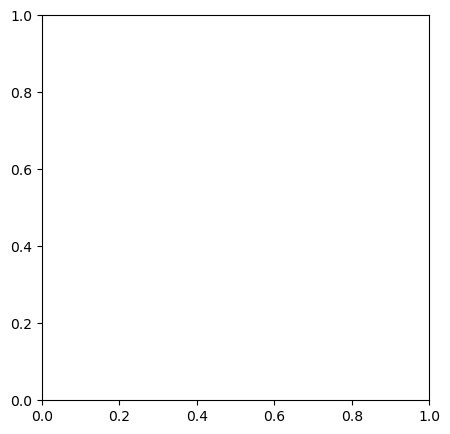

In [31]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib import colors 


axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

fig,ax = plt.subplots(1, num_axes, figsize=(5*num_axes, 5))
    # make scatter plot
    # ax[i].scatter(
    #     np.array(db[f"ndscan.rid_{RID}.points.axis_{i}"][1])/60,
    #     np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]),
    #     s=2,
    #     color='k',
    # )

    # ax[i].set_xlabel(axes[i]["param"]["description"] + " (min)")
    # ax[i].set_ylabel("atom number")
    # ax[i].set_ylim(bottom=0)

numbers= np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots(atom < 30% mean )
# failed_shots = np.sum(numbers < 0.7 * np.mean(numbers))
failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e8:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")

# for i in range(1,num_axes):
#     ax[i].axhline(np.mean(numbers), color='b', linestyle='--', )
# ax[0].axhline(np.mean(numbers), color='b', linestyle='--', label='Mean = {:.2f}e8'.format(np.mean(numbers) / 1e8))
# ax[0].legend(loc="lower right")

# atom number and uncertainty
print(f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8")

# obtain current best optimization parameterss
objective = np.array(db.get(f"ndscan.rid_{RID}.points.channel_custom_objective")[1])
axes_array = np.array(db.get(f"ndscan.rid_{RID}.axes")[1])

# find best results 
best_index = np.argmin(objective)
best_objective = objective[best_index]
best_axes = {}
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best parameters: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best objective value: {best_objective}")
for name, value in best_axes.items():
    print(f"{name}: {value}")



In [32]:
# best index based on PSD
PSD = np.array(db.get(f"ndscan.rid_{RID}.points.channel_phase_space_density")[1])
best_index = np.argmax(PSD)
best_PSD = PSD[best_index]
best_axes = {}
best_sigma_x = db.get(f"ndscan.rid_{RID}.points.channel_sigmax_mm")[1][best_index]
best_sigma_y = db.get(f"ndscan.rid_{RID}.points.channel_sigmay_mm")[1][best_index]
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best PSD: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best PSD: {best_PSD:.2e}")
print(f"Best sigma_x: {best_sigma_x:.2f} mm")
print(f"Best sigma_y: {best_sigma_y:.2f} mm")
for name, value in best_axes.items():
    print(f"{name}: {value}")

# # make a scatter plot of atom number vs total time = axis_0 + axis_1
# fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
# t1 = db[f"ndscan.rid_{RID}.points.axis_1"][1]
# t2 = db[f"ndscan.rid_{RID}.points.axis_2"][1]
# N = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
# t_total = np.array(t1) + np.array(t2)
# t_frac = np.array(t1) / t_total

# ax[0].scatter(
#     t_total *1e3,
#     N,
#     s=2,color='k',)
# ax[0].set_xlabel("Total Time (ms)")
# ax[0].set_ylabel("Atom Number")
# ax[1].scatter(
#     t_frac,
#     N,
#     s=2,color='k',)
# ax[1].set_xlabel(f"Time Fraction : $t_{{ramp}}/t_{{total}}$")
# ax[1].set_ylabel("Atom Number")
# ax[0].set_title("Scatter Plot of Atom Number vs Total Time")
# ax[1].set_title("Scatter Plot of Atom Number vs Time Fraction")
# plt.show()



Atom number at best PSD: 1.82e8
Best PSD: 6.24e-08
Best sigma_x: 1.79 mm
Best sigma_y: 1.51 mm
Elapsed time: 149.63569952221587


In [33]:
# import numpy as np
# import matplotlib.pyplot as plt

# loading = np.asarray(db[f"ndscan.rid_{RID}.points.channel_mot_voltages"][1])

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# for i in range(len(numbers)):
#     color = 'r' if numbers[i] < 1e8 else 'b'
#     ax[1].plot(np.arange(0,30,3), loading[i], color=color, alpha=0.5, linewidth=0.5)

# ax[1].legend(title="Number of atoms", labels=["< 1e8", "> 1e8"])
# ax[1].set_xlabel("Loading time (s)")
# ax[1].set_ylabel("MOT photodiode voltage (V)")

# ax[0].scatter(
#     db[f"ndscan.rid_{RID}.points.axis_0"][1],
#     db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
#     s=2,
#     color=['r' if n < 1e8 else 'b' for n in numbers])
# ax[0].axhline(1e8, color='k', linestyle='--', linewidth=0.5)
# ax[0].set_xlabel(axes[0]["param"]["description"])
# ax[0].set_ylabel("Number of atoms")